In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
import os
import numpy as np
import scanpy as sc
#import PyWGCNA
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score
from scipy.stats import mannwhitneyu, false_discovery_control
import re
from itertools import combinations
from scipy.stats import pearsonr
import ast

In [21]:
def stack_triangle(df, col):
    df = pd.DataFrame(
        df.where(
            np.tri(
                df.shape[0],
                dtype=bool,
                k=-1
            ),
            np.nan
        ).stack(dropna=True), columns=[col] 
    )
    
    return df


In [22]:
# Function that generates and saves the ROC curve
def generate_roc_curve(
    data,
    target_col,
    feature_col,
):
    # ROC curve using all gene pairs
    fpr, tpr, thr = roc_curve(data[target_col], data[feature_col])
    auroc = roc_auc_score(data[target_col], data[feature_col])
    
    return fpr, tpr, thr, auroc

In [23]:
def fig_to_panels(fig, axes, output_dir):
    # Save individual panels of a figure 
    os.makedirs(output_dir, exist_ok=True)
    
    for panel_name, ax in axes.items():
        # Extract the panel title
        panel_title = ax.get_title()

        # Sanitize the panel title to use in filenames
        safe_title = panel_title.replace(" ", "_").replace("/", "_").replace("\n", "_").lower()

        # Create the filename for the current panel
        output_file = os.path.join(output_dir,safe_title)

        # Adjust the bounding box to include everything (labels, titles, etc.)
        extent = ax.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())

        # Save the individual panel using the adjusted bounding box
        fig.savefig(output_file + '.pdf', bbox_inches=extent, dpi=300)
        fig.savefig(output_file + '.png', bbox_inches=extent)

        print(f"Saved panel '{panel_title}' to {output_file}")


In [24]:
# Define colors
# Light version is obtained by setting alpha=0.5

ncolor  = '#00728eff' # solid dark
ncolor2 = '#00728e80' # alpha=0.5
lightncolor = '#7fb8c6ff' # solid light

tcolor  = '#ab3502ff'
tcolor2 = '#ab350280'
lighttcolor = '#d49980ff'

graycolor = '#4D4E4FFF'
graycolor2 ='#4d4e4f80'

lightgray = '#C8CAD4'

orangecolor = '#e69426'
orangecolor2 = '#e6942680'
lightorangecolor = '#f2c992ff'

In [25]:
def network_to_adj(network_path):
    network = pd.read_csv(
        network_path,
        usecols=['complex1', 'complex2', 'adj']
    )

    # Add a mirrored version of the network to make it symmetric
    network_mirrored = network.copy()
    network_mirrored.columns = ['complex2', 'complex1', 'adj']
    network = pd.concat([network, network_mirrored], ignore_index=True)

    adj = network.pivot(index='complex1', columns='complex2', values='adj').fillna(0)
    return adj

# Motifs

In [26]:
import matplotlib.image as mpimg
from matplotlib.lines import Line2D

def read_and_plot_motifs(folder, color=orangecolor, return_fig=False, predetermined=True):
    fs = 18
    scaling_factor=1.05
    
    df          = pd.read_csv(os.path.join(folder, 'motifs_permutations.csv'))
    real_counts = pd.read_csv(os.path.join(folder, 'counts.csv'), index_col='motif')
    
    perm_triplets = df[['3_path', '3_clique']].sum(1)
    real_triplets = real_counts.T[['3_path', '3_clique']].loc['number'].sum()

    perm_quadruplets = df.sum(1) - perm_triplets
    real_quadruplets = real_counts.values.sum() - real_triplets
    
    # TRIPLETS AND QUADRUPLETS COUNTS

    data = pd.DataFrame({
        'Triplets': perm_triplets,
        'Quadruplets': perm_quadruplets
    })
    df_long = data.melt(var_name="Feature", value_name="Value")

    if predetermined:
        sorted_features_1 = ['Quadruplets', 'Triplets']
        sorted_features_2 = ['3_path', '3_clique']
        sorted_features_3 = [
            '4_triangle_extra', '4_path', '4_one_missing',
            '4_no_crosstalk', '4_cycle', '4_clique'
        ]
    else:
        sorted_features_1 = df_long.groupby("Feature")["Value"].median().sort_values(ascending=False).index.tolist()
        sorted_features_2 = perm_3_fracs_long.groupby("Feature")["Value"].median().sort_values(ascending=False).index.tolist()
        sorted_features_3 = perm_4_fracs_long.groupby("Feature")["Value"].median().sort_values(ascending=False).index.tolist()

    
    real_values = [real_triplets, real_quadruplets]

    # TRIPLETS FRACTIONS

    real_3_fracs = real_counts.loc[['3_path', '3_clique']] / real_triplets
    perm_3_fracs = (df[['3_path', '3_clique']].T / perm_triplets).T

    perm_3_fracs_long = perm_3_fracs.melt(var_name="Feature", value_name="Value")
    real_3_values = real_3_fracs.values.flatten()  # Flatten to align with feature order

    # QUADRUPLETS FRACTIONS

    cols = [col for col in df.columns if col not in ['3_path', '3_clique']]

    real_4_fracs = real_counts.loc[cols] / real_quadruplets
    perm_4_fracs = (df[cols].T / perm_quadruplets).T

    perm_4_fracs_long = perm_4_fracs.melt(var_name="Feature", value_name="Value")
    real_4_values = real_4_fracs.values.flatten()  # Flatten to align with feature order
    

    # ----- PLOT ------
    
    fig, axs = plt.subplot_mosaic(
        '''
        ABCCC
        ''',
        figsize=(18, 6)
    )

    style = dict(marker='s', linestyle=' ', markersize=10,
                 markerfacecolor=color, markeredgecolor='k')

    # Plot 1: Permuted and Real Counts (sorted by median, descending)
    #sorted_features_1 = df_long.groupby("Feature")["Value"].median().sort_values(ascending=False).index
    df_long_sorted = df_long[df_long["Feature"].isin(sorted_features_1)]
    df_long_sorted['Value'] = np.log10(df_long_sorted['Value'])

    real_values_series_1 = np.log10(pd.Series(real_values, index=df_long["Feature"].unique()))
    real_values_sorted_1 = real_values_series_1.loc[sorted_features_1]

    # Plot log10 counts on a linear scale
    #real_values_sorted_1 = np.log10(real_values_sorted_1)
    #log_values_sorted_1 = np.log10(df_long_sorted.groupby("Feature")["Value"].median().loc[sorted_features_1])

    #sns.boxplot(x="Feature", y="Value", data=df_long_sorted, color=lightgray, order=sorted_features_1, ax=axs['A'], whis=(2.5, 97.5))
    sns.violinplot(x="Feature", y="Value", data=df_long_sorted, color=lightgray, order=sorted_features_1, ax=axs['A'])

    #axs['A'].plot(range(len(real_values_sorted_1)), real_values_sorted_1, **style)
    axs['A'].plot(range(len(real_values_sorted_1)), real_values_sorted_1, **style, label='log10 Counts')
    axs['A'].set_title("Total Occurrences", fontdict={'fontsize': fs})
    axs['A'].set_ylabel("log$_{10}$(Counts)", fontdict={'fontsize': fs})
    axs['A'].set_xlabel("Feature", fontdict={'fontsize': fs})

    # Plot 2: Fractions of Triplets (sorted by median, descending)
    #sorted_features_2 = perm_3_fracs_long.groupby("Feature")["Value"].median().sort_values(ascending=False).index
    perm_3_fracs_sorted = perm_3_fracs_long[perm_3_fracs_long["Feature"].isin(sorted_features_2)]

    real_3_values_series = pd.Series(real_3_values, index=perm_3_fracs_long["Feature"].unique())
    real_3_values_sorted = real_3_values_series.loc[sorted_features_2]

    #sns.boxplot(x="Feature", y="Value", data=perm_3_fracs_sorted, color=lightgray, order=sorted_features_2, ax=axs['B'], whis=(2.5, 97.5))
    sns.violinplot(x="Feature", y="Value", data=perm_3_fracs_sorted, color=lightgray, order=sorted_features_2, ax=axs['B'])
    
    axs['B'].plot(range(len(real_3_values_sorted)), real_3_values_sorted, **style)
    axs['B'].set_title("Distribution of Triplets", fontdict={'fontsize': fs})
    axs['B'].set_ylabel("Proportion", fontdict={'fontsize': fs})
    axs['B'].set_xlabel("Feature", fontdict={'fontsize': fs})
    axs['B'].set_xticks(range(len(real_3_values_sorted)))

    # Plot 3: Fractions of Quadruplets (sorted by median, descending)
    #sorted_features_3 = perm_4_fracs_long.groupby("Feature")["Value"].median().sort_values(ascending=False).index
    perm_4_fracs_sorted = perm_4_fracs_long[perm_4_fracs_long["Feature"].isin(sorted_features_3)]

    real_4_values_series = pd.Series(real_4_values, index=perm_4_fracs_long["Feature"].unique())
    real_4_values_sorted = real_4_values_series.loc[sorted_features_3]

    #sns.boxplot(x="Feature", y="Value", data=perm_4_fracs_sorted, color=lightgray, order=sorted_features_3, ax=axs['C'], whis=(2.5, 97.5))
    sns.violinplot(x="Feature", y="Value", data=perm_4_fracs_sorted, color=lightgray, order=sorted_features_3, ax=axs['C'])

    axs['C'].plot(range(len(real_4_values_sorted)), real_4_values_sorted, **style)
    axs['C'].set_title("Distribution of Quadruplets", fontdict={'fontsize': fs})
    axs['C'].set_ylabel("Proportion", fontdict={'fontsize': fs})
    axs['C'].set_xlabel("Feature", fontdict={'fontsize': fs})
    axs['C'].set_xticks(range(len(real_4_values_sorted)))

    # Adjust the label padding dynamically based on the image height
    img_dir = '/home/lnemati/pathway_crosstalk/data/motifs_icons/'
    img_width = 0.15 * scaling_factor# Increased image width for larger icons
    img_height = img_width  # Keep aspect ratio the same

    # Get the position of the main axes for all subplots
    for ax_name in ['A', 'B', 'C']:
        ax = axs[ax_name]
        xl, yl, xh, yh = np.array(ax.get_position()).ravel()
        w = xh - xl
        h = yh - yl

        # Calculate dynamic labelpad based on image height
        figure_height_in_inches = fig.get_size_inches()[1]
        figure_to_axes_ratio = h / figure_height_in_inches
        dynamic_labelpad = img_height / figure_to_axes_ratio * 72  # Convert to points (1 inch = 72 points)
        #ax.set_xlabel("Feature", labelpad=dynamic_labelpad)

        # Loop through x-axis labels and place an image for each feature
        for i, label in enumerate(sorted_features_1 if ax_name == 'A' else (sorted_features_2 if ax_name == 'B' else sorted_features_3)):
            img_path = os.path.join(img_dir, f"{label}.png")

            if os.path.exists(img_path):
                img = mpimg.imread(img_path)

                # Get the x-coordinate of the current feature label (in data coordinates)
                label_display_coords = ax.get_xticklabels()[i].get_position()  # Get the label position directly
                label_x = label_display_coords[0]  # Extract the x-coordinate of the label

                # Transform the label's x-coordinate from data coordinates to figure coordinates
                label_display_coords = ax.transData.transform((label_x, 0))  # Data to figure
                fig_coords = fig.transFigure.inverted().transform(label_display_coords)  # Figure coordinates

                # Center the image over the x-axis label
                xpos = fig_coords[0] - img_width / 2  # Adjust x position to center image
                ypos = yl - img_height - 0.03  # Adjust y position below the x-axis labels

                # Add new axes for the image
                ax_img = fig.add_axes([xpos, ypos, img_width, img_height])
                ax_img.axison = False
                ax_img.imshow(img)

    # Remove grid from all subplots
    for ax_name in ['A', 'B', 'C']:
        axs[ax_name].grid(False)

    # Make axes black
    for ax_name in ['A', 'B', 'C']:
        ax = axs[ax_name]
        ax.spines[['bottom', 'left']].set_color('black')
        ax.spines[['right', 'top']].set_visible(False)

    # Manually adjust subplot spacing (remove tight_layout)
    #plt.subplots_adjust(left=0.07, right=0.93, top=0.93, bottom=0.15)
    lp = 85

    axs['A'].set_xlabel("Group", labelpad=lp)
    axs['A'].set_xticks([])
    axs['B'].set_xlabel("Motif", labelpad=lp)
    axs['B'].set_xticks([])
    axs['C'].set_xlabel("Motif", labelpad=lp)
    axs['C'].set_xticks([])

    handles = [
        Line2D(
            [0], [0], marker='o', color='w', markerfacecolor=color, 
            markeredgecolor='k', markersize=10, label='Observed Value'
        ),
        Line2D(
            [0], [0], marker='s', color='w', markerfacecolor=lightgray, 
            markeredgecolor='lightgray', markersize=10, label='Ensemble (Permutations)'
        ),
    ]


    axs['A'].set_ylim(bottom=0)
    axs['B'].set_ylim(bottom=0)
    axs['C'].legend(handles, ['Observed Value', 'Ensemble (Permutations)'], loc='upper right')

    #plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/crosstalk/motifs_tumor.pdf', bbox_inches='tight')
    #plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/crosstalk/motifs_tumor.png', bbox_inches='tight')
    #plt.savefig('/home/lnemati/pathway_crosstalk/results/revision/images/motifs_violinplots_double.png', bbox_inches='tight', dpi=300)
    #plt.savefig('/home/lnemati/pathway_crosstalk/results/revision/images/motifs_violinplots_double.pdf', bbox_inches='tight', dpi=300)

    
    if return_fig:
        return fig
    else:
        plt.show()


/var/tmp/pbs.439896.pbs01/ipykernel_81483/2331160255.py:11: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  perm_triplets = df[['3_path', '3_clique']].sum(1)
/var/tmp/pbs.439896.pbs01/ipykernel_81483/2331160255.py:14: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  perm_quadruplets = df.sum(1) - perm_triplets


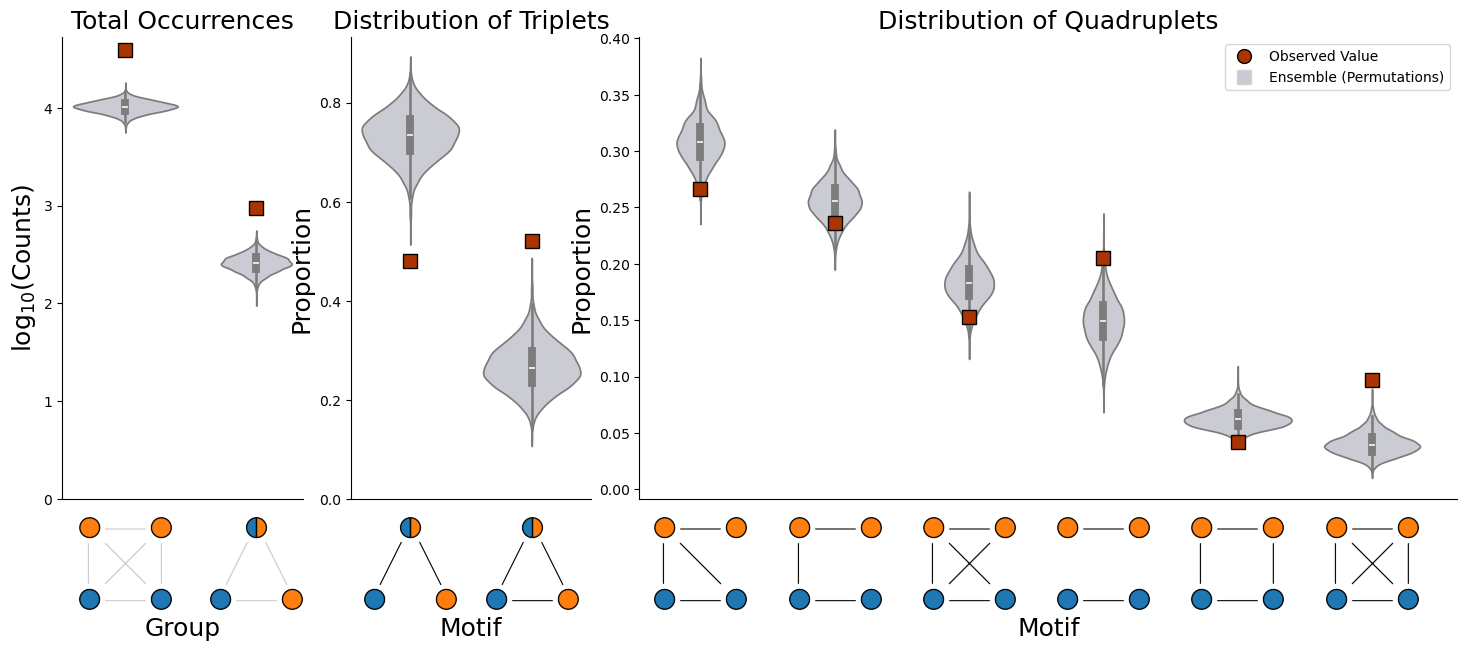

In [27]:
#read_and_plot_motifs('/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/motifs/both', color='k')
#read_and_plot_motifs('/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/motifs/normal', color=ncolor)
fig = read_and_plot_motifs('/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/motifs/tumor', color=tcolor)


/var/tmp/pbs.439896.pbs01/ipykernel_81483/2331160255.py:11: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  perm_triplets = df[['3_path', '3_clique']].sum(1)
/var/tmp/pbs.439896.pbs01/ipykernel_81483/2331160255.py:14: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  perm_quadruplets = df.sum(1) - perm_triplets


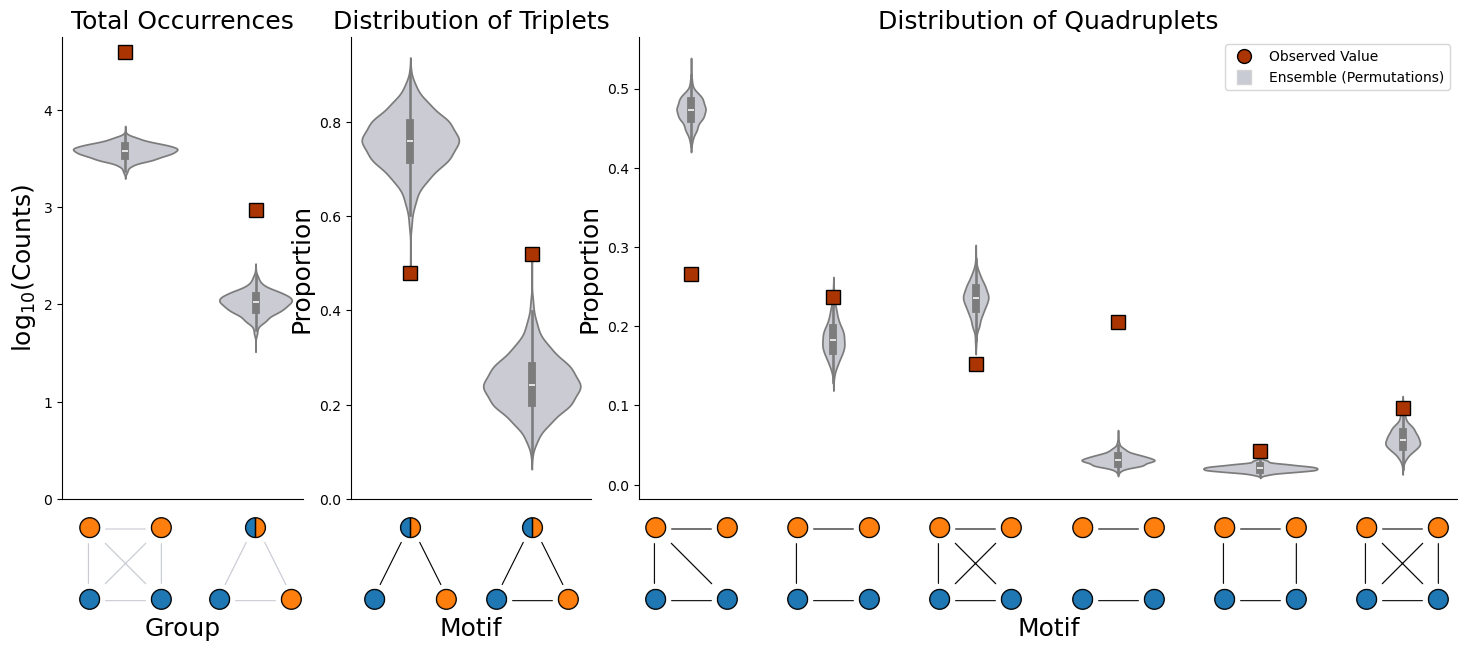

In [28]:

fig = read_and_plot_motifs('/home/lnemati/pathway_crosstalk/results/crosstalk/new_rewiring_shuffle/tumor/both_shuffle', color=tcolor)

In [29]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg
from matplotlib.lines import Line2D


def read_and_plot_motifs_two_ensembles(folder1, folder2, color=orangecolor):

    fs = 18
    scaling_factor = 1.05

    # =========================
    # LOAD DATA
    # =========================
    df1 = pd.read_csv(os.path.join(folder1, 'motifs_permutations.csv'))
    df2 = pd.read_csv(os.path.join(folder2, 'motifs_permutations.csv'))

    real_counts = pd.read_csv(
        os.path.join(folder1, 'counts.csv'),
        index_col='motif'
    )

    triplet_features = ['3_path', '3_clique']
    quad_features = [c for c in df1.columns if c not in triplet_features]

    # =========================
    # ENSEMBLE BUILDER
    # =========================
    def build(df, label):
        trip = df[triplet_features].sum(1)
        quad = df.sum(1) - trip

        perm_3 = (df[triplet_features].T / trip).T.melt(var_name="Feature", value_name="Value")
        perm_4 = (df[quad_features].T / quad).T.melt(var_name="Feature", value_name="Value")

        perm_3["Permutation"] = label
        perm_4["Permutation"] = label

        return perm_3, perm_4, trip, quad

    perm_3_1, perm_4_1, trip1, quad1 = build(df1, "Single Rewiring")
    perm_3_2, perm_4_2, trip2, quad2 = build(df2, "Dual Rewiring")

    perm_3_all = pd.concat([perm_3_1, perm_3_2])
    perm_4_all = pd.concat([perm_4_1, perm_4_2])

    # =========================
    # OBSERVED VALUES
    # =========================
    real_3 = real_counts.loc[triplet_features] / real_counts.loc[triplet_features].sum().values
    real_4 = real_counts.loc[quad_features] / real_counts.loc[quad_features].sum().values

    # =========================
    # ORDER (OBSERVED DESCENDING)
    # =========================
    order_3 = real_3.iloc[:, 0].sort_values(ascending=False).index.tolist()
    order_4 = real_4.iloc[:, 0].sort_values(ascending=False).index.tolist()

    # =========================
    # FIGURE
    # =========================
    fig, axs = plt.subplot_mosaic(
        '''
        AB
        ''',
        figsize=(9, 3),
        width_ratios=[1, 3]
    )

    ax3 = axs['A']
    ax4 = axs['B']

    style = dict(
        marker='o',
        linestyle=' ',
        markersize=5,
        markerfacecolor=color,
        markeredgecolor='k'
    )

    # =========================
    # PANEL A (TRIPLETS)
    # =========================
    sns.violinplot(
        data=perm_3_all,
        x="Feature",
        y="Value",
        hue="Permutation",
        order=order_3,
        split=True,
        inner=None,
        ax=ax3,
        palette=["steelblue", "darkorange"]
    )

    ax3.plot(
        np.arange(len(order_3)),
        real_3.loc[order_3].values.flatten(),
        **style
    )

    ax3.set_title("Triplet Fractions", fontsize=fs)

    # =========================
    # PANEL B (QUADRUPLETS)
    # =========================
    sns.violinplot(
        data=perm_4_all,
        x="Feature",
        y="Value",
        hue="Permutation",
        order=order_4,
        split=True,
        inner=None,
        ax=ax4,
        palette=["steelblue", "darkorange"]
    )

    ax4.plot(
        np.arange(len(order_4)),
        real_4.loc[order_4].values.flatten(),
        **style
    )

    ax4.set_title("Quadruplet Fractions", fontsize=fs)

    # =========================
    # ICONS (UNCHANGED)
    # =========================
    img_dir = '/home/lnemati/pathway_crosstalk/data/motifs_icons/'
    img_width = 0.15 * scaling_factor

    for ax_name, features in zip(['A', 'B'], [order_3, order_4]):

        ax = axs[ax_name]
        xl, yl, xh, yh = np.array(ax.get_position()).ravel()

        for i, label in enumerate(features):
            img_path = os.path.join(img_dir, f"{label}.png")
            if not os.path.exists(img_path):
                continue

            img = mpimg.imread(img_path)

            label_display_coords = ax.get_xticklabels()[i].get_position()
            label_x = label_display_coords[0]

            label_display_coords = ax.transData.transform((label_x, 0))
            fig_coords = fig.transFigure.inverted().transform(label_display_coords)

            xpos = fig_coords[0] - img_width / 2
            ypos = yl - img_width - 0.03

            ax_img = fig.add_axes([xpos, ypos, img_width, img_width])
            ax_img.axis("off")
            ax_img.imshow(img)

    # =========================
    # CLEANUP
    # =========================
    for ax in axs.values():
        ax.grid(False)
        ax.spines[['top', 'right']].set_visible(False)

        # hide x-axis labels completely
        ax.set_xlabel("")
        ax.set_xticks([])

        if ax.get_legend() is not None:
            ax.get_legend().remove()

    handles = [
        Line2D([0], [0], marker='o', linestyle='',
               markerfacecolor=color, markeredgecolor='k',
               markersize=10, label='Observed'),

        Line2D([0], [0], marker='s', linestyle='',
               markerfacecolor='steelblue', markeredgecolor='steelblue',
               markersize=10, label='Single Rewiring'),

        Line2D([0], [0], marker='s', linestyle='',
               markerfacecolor='darkorange', markeredgecolor='darkorange',
               markersize=10, label='Dual Rewiring'),
    ]

    ax4.legend(handles=handles, loc='upper right')

    plt.savefig('/home/lnemati/pathway_crosstalk/results/revision/images/motifs_violinplots_both.png', bbox_inches='tight', dpi=300)

    plt.show()
    return fig

/var/tmp/pbs.439896.pbs01/ipykernel_81483/2941942245.py:33: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  trip = df[triplet_features].sum(1)
/var/tmp/pbs.439896.pbs01/ipykernel_81483/2941942245.py:34: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  quad = df.sum(1) - trip
/var/tmp/pbs.439896.pbs01/ipykernel_81483/2941942245.py:33: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  trip = df[triplet_features].sum(1)
/var/tmp/pbs.439896.pbs01/ipykernel_81483/2941942245.py:34: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  quad = df.sum(1) - trip


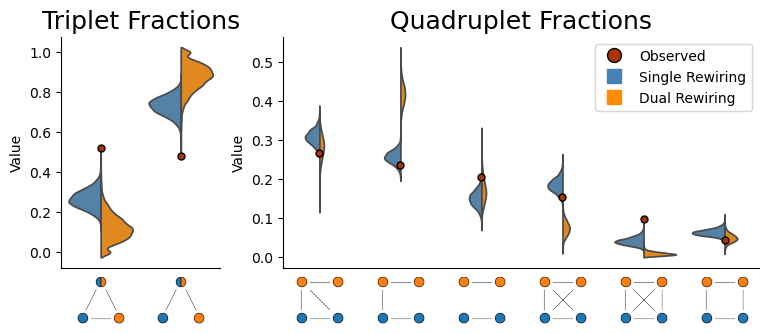

In [30]:
fig = read_and_plot_motifs_two_ensembles(
    '/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/motifs/tumor',
    '/home/lnemati/pathway_crosstalk/results/crosstalk/new_rewiring_shuffle2/tumor/both_shuffle',
    color=tcolor
)



/var/tmp/pbs.439896.pbs01/ipykernel_81483/924537514.py:10: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  perm_triplets = df[['3_path', '3_clique']].sum(1)
/var/tmp/pbs.439896.pbs01/ipykernel_81483/924537514.py:13: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  perm_quadruplets = df.sum(1) - perm_triplets


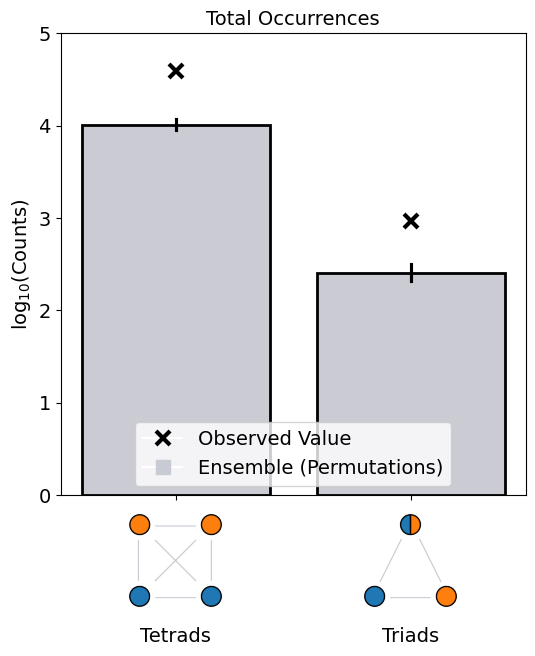

In [31]:
import matplotlib.image as mpimg
from matplotlib.lines import Line2D

def read_and_plot_motifs(folder, color=orangecolor, ax=None, return_fig=False, fs=14):
    scaling_factor = 1.05
    
    df          = pd.read_csv(os.path.join(folder, 'motifs_permutations.csv'))
    real_counts = pd.read_csv(os.path.join(folder, 'counts.csv'), index_col='motif')
    
    perm_triplets = df[['3_path', '3_clique']].sum(1)
    real_triplets = real_counts.T[['3_path', '3_clique']].loc['number'].sum()

    perm_quadruplets = df.sum(1) - perm_triplets
    real_quadruplets = real_counts.values.sum() - real_triplets
    
    data = pd.DataFrame({
        'Triads': perm_triplets,
        'Tetrads': perm_quadruplets
    })
    df_long = data.melt(var_name="Feature", value_name="Value")

    real_values = [real_triplets, real_quadruplets]
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    else:
        fig = ax.figure

    style = dict(marker='x', linestyle=' ', markersize=10, markeredgewidth=3,
                 markerfacecolor=color, markeredgecolor='k')

    sorted_features_1 = df_long.groupby("Feature")["Value"].median().sort_values(ascending=False).index
    df_long_sorted = df_long[df_long["Feature"].isin(sorted_features_1)]
    df_long_sorted['Value'] = np.log10(df_long_sorted['Value'])

    real_values_series_1 = np.log10(pd.Series(real_values, index=df_long["Feature"].unique()))
    real_values_sorted_1 = real_values_series_1.loc[sorted_features_1]

    sns.barplot(
        x="Feature",
        y="Value",
        data=df_long_sorted,
        color=lightgray,
        order=sorted_features_1,
        ax=ax,
        estimator='mean',
        errorbar='sd',
        linewidth=2,
        edgecolor='k',
        err_kws={'color': 'black'}
    )

    ax.plot(range(len(real_values_sorted_1)), real_values_sorted_1, **style, label='log10 Counts')
    ax.set_title("Total Occurrences", fontdict={'fontsize': fs})
    ax.set_ylabel("log$_{10}$(Counts)", fontdict={'fontsize': fs})
    ax.set_xlabel("Feature", fontdict={'fontsize': fs}, labelpad=20)

    img_dir = '/home/lnemati/pathway_crosstalk/data/motifs_icons/'
    img_width = 0.15 * scaling_factor
    img_height = img_width  
    
    xl, yl, xh, yh = np.array(ax.get_position()).ravel()
    w = xh - xl
    h = yh - yl
    
    figure_height_in_inches = fig.get_size_inches()[1]
    figure_to_axes_ratio = h / figure_height_in_inches
    dynamic_labelpad = img_height / figure_to_axes_ratio * 72 + 3
    #ax.set_xlabel("Feature", fontdict={'fontsize': fs}, labelpad=dynamic_labelpad)
    ax.set_xlabel('')
    
    for i, label in enumerate(sorted_features_1):
        img_path = os.path.join(img_dir, f"{label}.png")
        if os.path.exists(img_path):
            img = mpimg.imread(img_path)
            label_display_coords = ax.get_xticklabels()[i].get_position()
            label_x = label_display_coords[0]
            label_display_coords = ax.transData.transform((label_x, 0))
            fig_coords = fig.transFigure.inverted().transform(label_display_coords)
            xpos = fig_coords[0] - img_width / 2
            ypos = yl - img_height - 0.03
            ax_img = fig.add_axes([xpos, ypos, img_width, img_height])
            ax_img.axison = False
            ax_img.imshow(img)
    
    handles = [
        Line2D([0], [0], marker='x', color='w', markerfacecolor=color, markeredgewidth=3,
               markeredgecolor='k', markersize=10, label='Observed Value'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor=lightgray, 
               markeredgecolor=lightgray, markersize=10, label='Ensemble (Permutations)'),
    ]
    
    ax.legend(handles=handles, loc='lower center', fontsize=fs)
    ax.set_ylim(0, 5)
    ax.tick_params(labelsize=fs)
    ax.tick_params(axis='x', which='major', pad=dynamic_labelpad)    
    
    if return_fig:
        return fig

        
fig = read_and_plot_motifs('/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/motifs/tumor', color=tcolor, return_fig=True)
fig.show()

In [32]:
#fig.savefig('/home/lnemati/pathway_crosstalk/results/figures/crosstalk/motifs_both_total.pdf', dpi=300, bbox_inches='tight')
#fig.savefig('/home/lnemati/pathway_crosstalk/results/figures/crosstalk/motifs_both_total.png', dpi=300, bbox_inches='tight')

In [33]:
#df = pd.read_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/motifs/tumor/motifs_permutations.csv')
#motifs = pd.read_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/motifs/tumor/counts.csv', index_col='motif')

df = pd.read_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/motifs/tumor/motifs_permutations.csv')
motifs = pd.read_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/motifs/tumor/counts.csv', index_col='motif')

motifs = motifs['number'] 

df3 = df[[col for col in df.columns if col.startswith('3')]]
df4 = df[[col for col in df.columns if col.startswith('4')]]
motifs3 = motifs.loc[[idx for idx in motifs.index if idx.startswith('3')]]
motifs4 = motifs.loc[[idx for idx in motifs.index if idx.startswith('4')]]

motifs3 = motifs3 / motifs3.sum()
motifs4 = motifs4 / motifs4.sum()
df3 = (df3.T / df3.sum(1)).T
df4 = (df4.T / df4.sum(1)).T

df = df3.join(df4)
motifs = pd.concat([motifs3, motifs4])

means = df.mean()
stds = df.std()

motifs_z = ((motifs - means) / stds).sort_values()
motifs_z.name = 'z'

/var/tmp/pbs.439896.pbs01/ipykernel_81483/3371500805.py:16: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  df3 = (df3.T / df3.sum(1)).T
/var/tmp/pbs.439896.pbs01/ipykernel_81483/3371500805.py:17: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  df4 = (df4.T / df4.sum(1)).T


In [34]:
import numpy as np

# Compute the reference distribution's center (e.g., median or mean)
null_center = np.mean(df, axis=0)

# Compute two-tailed p-values
p_values = ( (np.abs(motifs - null_center) <= np.abs(df - null_center)).sum(axis=0) ) / df.shape[0]
p_values = pd.Series(false_discovery_control(p_values), index=p_values.index)
p_values = p_values.loc[motifs_z.index]
p_values

motif
3_path              0.00000
4_cycle             0.02816
4_triangle_extra    0.03200
4_one_missing       0.10400
4_path              0.23500
4_no_crosstalk      0.01960
3_clique            0.00000
4_clique            0.00000
dtype: float64

In [35]:
# Compute the reference distribution's center (e.g., median or mean)
null_center = np.mean(df, axis=0)

# Count how many null samples are as extreme or more extreme
observed = (np.abs(motifs - null_center) <= np.abs(df - null_center)).sum(axis=0)

# Apply correction: (1 + observed) / (1 + total)
p_values = (1 + observed) / (1 + df.shape[0])

# Multiple testing correction
p_values = pd.Series(false_discovery_control(p_values), index=df.columns)

# Align index if needed
p_values = p_values.loc[motifs_z.index]

p_values

motif
3_path              0.000533
4_cycle             0.028474
4_triangle_extra    0.032260
4_one_missing       0.104208
4_path              0.235153
4_no_crosstalk      0.019996
3_clique            0.000533
4_clique            0.000533
dtype: float64

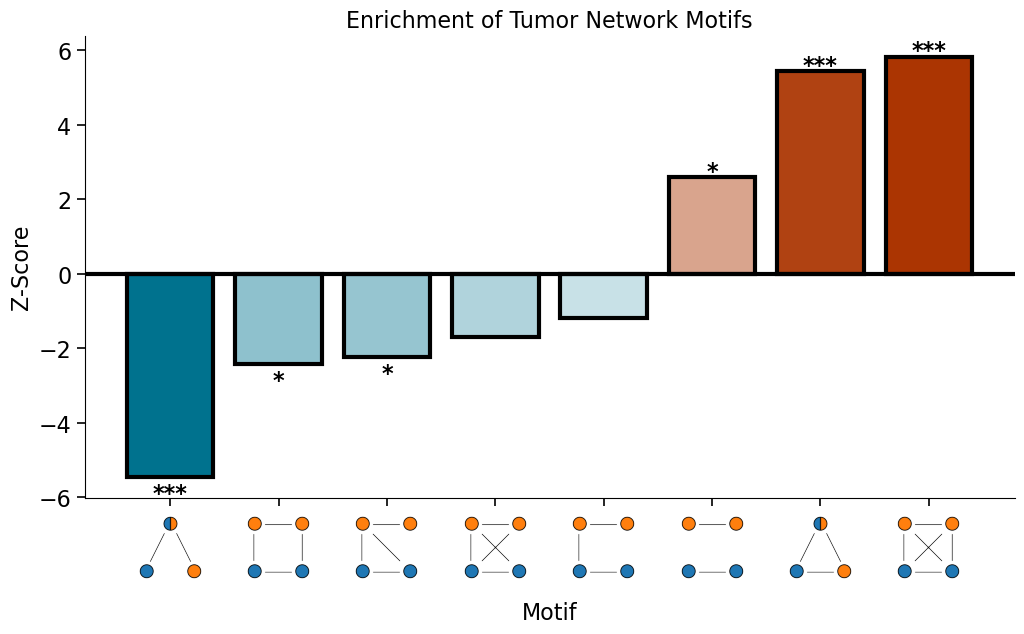

In [16]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.image as mpimg
import os

img_dir = '/home/lnemati/pathway_crosstalk/data/motifs_icons'
fs = 16

# Use your existing data
motifs = motifs_z.index  # Motif names (e.g., a pandas index)
z_scores = motifs_z.values  # Z-score values (e.g., from a pandas series)

# Create the custom colormap and normalize the z-scores
cmap = mcolors.LinearSegmentedColormap.from_list('custom_gradient', [ncolor, 'white', tcolor])
norm = mcolors.TwoSlopeNorm(vmin=z_scores.min(), vcenter=0, vmax=z_scores.max())
colors = cmap(norm(z_scores))

# Create the bar plot
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

bars = ax.bar(
    motifs,       # x values (motifs)
    z_scores,     # y values (z-scores)
    color=colors, # Assign the calculated colors
    edgecolor='k',
    linewidth=3,
)

# Set the image properties
img_width = 0.105  # Fraction of figure width
img_height = img_width  # Maintain aspect ratio

xl, yl, xh, yh = np.array(ax.get_position()).ravel()
w = xh - xl
h = yh - yl

# Calculate dynamic labelpad based on image height
figure_height_in_inches = fig.get_size_inches()[1]
figure_to_axes_ratio = h / figure_height_in_inches
dynamic_labelpad = img_height / figure_to_axes_ratio * 72  # Convert to points (1 inch = 72 points)

# Loop through each motif and replace its x-axis label with an image
for i, label in enumerate(motifs):
    img_path = os.path.join(img_dir, f"{label}.png")
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)

        # Get the x-coordinate of the current feature label (in data coordinates)
        label_display_coords = ax.get_xticklabels()[i].get_position()  # Get the label position directly
        label_x = label_display_coords[0]  # Extract the x-coordinate of the label

        # Transform the label's x-coordinate from data coordinates to figure coordinates
        label_display_coords = ax.transData.transform((label_x, 0))  # Data to figure
        fig_coords = fig.transFigure.inverted().transform(label_display_coords)  # Figure coordinates

        # Center the image over the x-axis label
        xpos = fig_coords[0] - img_width / 2  # Adjust x position to center image
        ypos = yl - img_height - 0.03  # Adjust y position below the x-axis labels

        # Add new axes for the image
        ax_img = fig.add_axes([xpos, ypos, img_width, img_height])
        ax_img.axison = False
        ax_img.imshow(img)

# Add a horizontal line at y=0
xlim = ax.get_xlim()
ax.hlines(0, xlim[0], xlim[1], color='k', linestyle='-', linewidth=3)
ax.set_xlim(xlim[0], xlim[1])

ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(labelsize=fs)

# Customize the plot
ax.set_title("Enrichment of Tumor Network Motifs", fontsize=16)
ax.set_xlabel("Motif", fontsize=fs)
ax.set_ylabel("Z-Score", fontsize=fs)
ax.set_xticklabels([])
ax.set_xlabel('Motif', labelpad=65)

# Define significance thresholds
sig_levels = {0.001: '***', 0.01: '**', 0.05: '*'}

# Loop through bars to annotate significance
for bar, z_score, p_val in zip(bars, z_scores, p_values):
    height = bar.get_height()
    sig_symbol = next((symbol for threshold, symbol in sig_levels.items() if p_val <= threshold), None)
    
    if sig_symbol:
        text_y = height + 0.15 if z_score > 0 else height - 0.15  # Adjust position based on sign
        ax.text(
            bar.get_x() + bar.get_width() / 2,  # X position (center of bar)
            text_y,  # Y position
            sig_symbol,
            ha='center',
            va='center' if z_score > 0 else 'top',  # Adjust vertical alignment
            fontsize=fs,
            fontweight='bold'
        )

# Add a legend for significance symbols with monospaced font
legend_labels = [
    "*   (p ≤ 0.05)",
    "**  (p ≤ 0.01)",
    "*** (p ≤ 0.001)",
]
legend_patches = [
    plt.Line2D([0], [0], color='black', lw=0, marker='', markersize=10, label=label) for label in legend_labels
]
#ax.legend(handles=legend_patches, loc='upper left', fontsize=fs-3, title='Permutation Test', frameon=False)

#plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/crosstalk/tumor_motifs_enrichment.pdf', bbox_inches='tight', dpi=300)
#plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/crosstalk/tumor_motifs_enrichment.png', bbox_inches='tight')

ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.get_xaxis().set_visible(True)
ax.get_yaxis().set_visible(True)

ax.tick_params(
    axis='both',
    which='both',
    labelsize=fs,
    direction='out',
    length=6,
    width=1.2,
    colors='black'
)

plt.show()

In [18]:
p_values

motif
3_path              0.00000
4_cycle             0.02816
4_triangle_extra    0.03200
4_one_missing       0.10400
4_path              0.23500
4_no_crosstalk      0.01960
3_clique            0.00000
4_clique            0.00000
dtype: float64

In [17]:
tumor_cliques = pd.read_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/motifs/tumor/motifs.csv').query('Type in ["3_clique", "4_clique"]')
tumor_cliques['all_genes'] = tumor_cliques['Interaction'].apply(lambda x: re.split(r'[+_&]', x))

all_genes = list(set(tumor_cliques['all_genes'].sum()))

gene_occurrences = {}
for gene in all_genes:
    gene_occurrences[gene] = tumor_cliques['all_genes'].apply(lambda x: gene in x).sum()
gene_occurrences = pd.Series(gene_occurrences).sort_values(ascending=False)
gene_occurrences.sort_values(ascending=False, inplace=True)
gene_occurrences.head(20)

ITGB1     960
CD4       925
CXCR3     684
ITGA11    434
CCR5      431
CCL8      406
ITGB2     320
CD8A      319
CD8B      317
CD80      293
CXCL13    266
CCR1      244
CCL5      241
ACKR1     240
CTLA4     239
CD86      237
CD28      237
CCR4      236
CXCL11    235
CXCL10    232
dtype: int64

# Cliques Hallmarks

In [20]:
import pandas as pd
import re

# Load hallmark gene sets
def read_gmt(file_path):
    gene_sets = {}
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) >= 3:
                gene_sets[parts[0]] = set(parts[2:])
    return gene_sets

# Load hallmark data
hallmarks_path = '/home/lnemati/resources/msigdb_hallmarks/h.all.v2024.1.Hs.symbols.gmt'
hallmarks = read_gmt(hallmarks_path)

# Generate readable labels
labels = [label.replace('HALLMARK_', '').replace('_', ' ').title() for label in hallmarks.keys()]

# Mapping for special formatting
replace = {
    'Myc': 'MYC',
    'Kras': 'KRAS',
    'Il2': 'IL2',
    'Stat5': 'STAT5',
    'Il6': 'IL6',
    'Jak': 'JAK',
    'Stat3': 'STAT3',
    'P53': 'P53',
    'Tnfa': 'TNFα',
    'Nfkb': 'NF-κB',
    'Mtorc1': 'MTORC1',
    ' Dn': ' Down',
    'Epithelial Mesenchymal Transition': 'E-M Transition'
}

# Apply replacements to labels
for str1, str2 in replace.items():
    labels = [label.replace(str1, str2) for label in labels]

# Map original hallmark names to cleaned labels
hallmark_name_map = dict(zip(hallmarks.keys(), labels))

# Load cliques
tumor_cliques = pd.read_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/motifs/tumor/motifs.csv')
tumor_cliques = tumor_cliques.query('Type in ["3_clique", "4_clique"]')

# Parse gene lists from interactions
tumor_cliques['all_genes'] = tumor_cliques.Interaction.apply(lambda x: re.split(r'[+_&]', x))

# Identify overlapping hallmark names (original form)
def find_matching_hallmarks(gene_list, hallmark_sets):
    return [name for name, genes in hallmark_sets.items() if set(gene_list) & genes]

# Assign original hallmark names per row
tumor_cliques['hallmarks'] = tumor_cliques['all_genes'].apply(lambda genes: find_matching_hallmarks(genes, hallmarks))

# Convert to readable labels
tumor_cliques['hallmarks'] = tumor_cliques['hallmarks'].apply(
    lambda hlist: [hallmark_name_map[h] for h in hlist]
)

# Extract all hallmark
all_hallmarks = sorted(set(sum(tumor_cliques['hallmarks'], [])))

# Add True/False column for each readable hallmark label
for label in all_hallmarks:
    tumor_cliques[label] = tumor_cliques['hallmarks'].apply(lambda x: label in x)

# Optional: drop raw 'hallmarks' and 'all_genes' columns
# tumor_cliques.drop(columns=['hallmarks', 'all_genes'], inplace=True)


In [21]:
#tumor_cliques.to_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/motifs/tumor/cliques_with_hallmarks.csv')

/home/lnemati/.conda/envs/new_cci_paper/lib/python3.11/site-packages/upsetplot/plotting.py:795: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  styles["linewidth"].fillna(1, inplace=True)
/home/lnemati/.conda/envs/new_cci_paper/lib/python3.11/site-packages/upsetplot/plotting.py:796: ChainedAssignmentError: A value is being set on a cop

ValueError: Invalid RGBA argument: nan

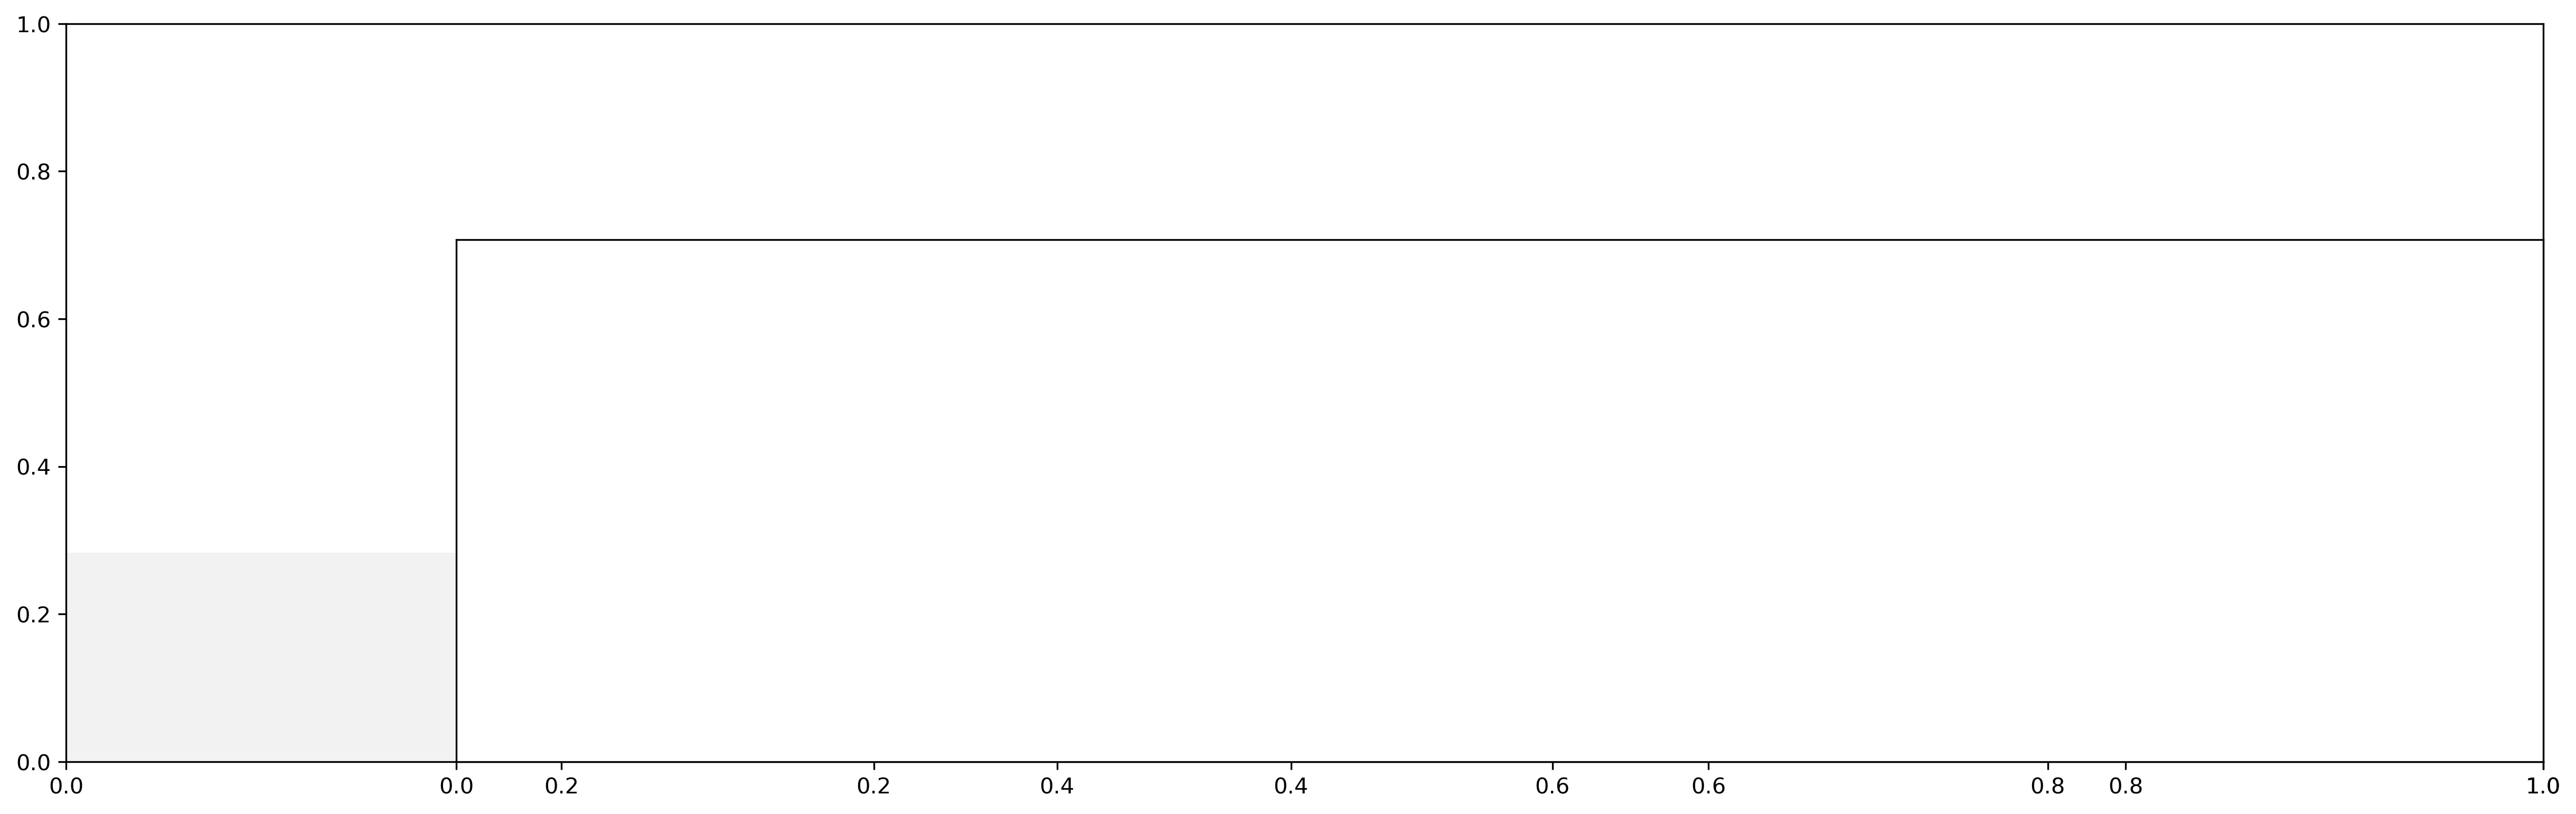

In [22]:
from upsetplot import UpSet, from_memberships, from_indicators, plot

fig, ax = plt.subplots(1,1, figsize=(7.08, 7.08), dpi=300)


top_N = 15
#max_n_bars = 51

top_hallmarks = tumor_cliques[all_hallmarks].sum().sort_values().tail(top_N)[::-1].index

upset_data = from_indicators(
    #all_hallmarks,
    top_hallmarks,
    data=tumor_cliques
)

#upset = UpSet(
#
#)

plot(
    data=upset_data,
    sort_by='cardinality',
    #min_subset_size=25,
    max_subset_rank=60,
    min_degree=2,
    #facecolor=tcolor,
    show_counts=True,
    fig=fig,
    element_size=20.75,
)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_xticks([])
ax.set_yticks([])
 
plt.suptitle(f"", y=1.05, fontsize=15)
#plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/crosstalk/hallmarks/hallmarks_upset.pdf', dpi=300, bbox_inches='tight')
#plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/crosstalk/hallmarks/hallmarks_upset.png', dpi=300, bbox_inches='tight')

plt.show()


In [23]:
## upset_table = upset_data.set_index('Interaction')
upset_table.index.name = 'circuit'
upset_table = upset_table.drop(columns=['all_genes', 'hallmarks', 'density'])
upset_table = upset_table.rename(columns={'Type': 'motif'})
#upset_table.to_csv('/home/lnemati/pathway_crosstalk/results/supplementary/cliques_with_hallmarks.csv')

NameError: name 'upset_table' is not defined

In [24]:
all_motifs = pd.read_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/motifs/both/motifs.csv')
motifs_to_plot = all_motifs.query('Type in ["3_clique", "4_clique"]')['Interaction']
#motifs_to_plot = all_motifs['Interaction']

In [25]:
net = pd.read_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/network_filtered.csv')
net['sign'] = np.where(net['auroc'] > 0.5, +1, -1)
net = net[['complex1', 'complex2', 'sign']]

In [26]:
net_mirror = net.copy()
net_mirror.columns = ['complex2', 'complex1', 'sign']
net_mirror = net_mirror[['complex1', 'complex2', 'sign']]
net = pd.concat([net, net_mirror]).set_index(['complex1', 'complex2'])
net = net['sign']

In [27]:
motifs_to_plot = motifs_to_plot.str.split('&', expand=True)
motifs_to_plot.columns = ['int1', 'int2']

In [28]:
motifs_to_plot['sign1'] = motifs_to_plot['int1'].apply(lambda x: net.loc[(x.split('+')[0],x.split('+')[1])])
motifs_to_plot['sign2'] = motifs_to_plot['int2'].apply(lambda x: net.loc[(x.split('+')[0],x.split('+')[1])])
motifs_to_plot = motifs_to_plot.set_index(['int1', 'int2'])

In [29]:
motifs_to_plot['result'] = 'Discordant'
motifs_to_plot['result'] = np.where((motifs_to_plot.sign1 == 1 ) & (motifs_to_plot.sign2 == 1 ), 'Tumor', motifs_to_plot['result'])
motifs_to_plot['result'] = np.where((motifs_to_plot.sign1 == -1) & (motifs_to_plot.sign2 == -1), 'Normal', motifs_to_plot['result'])

In [30]:
counts = motifs_to_plot['result'].value_counts()

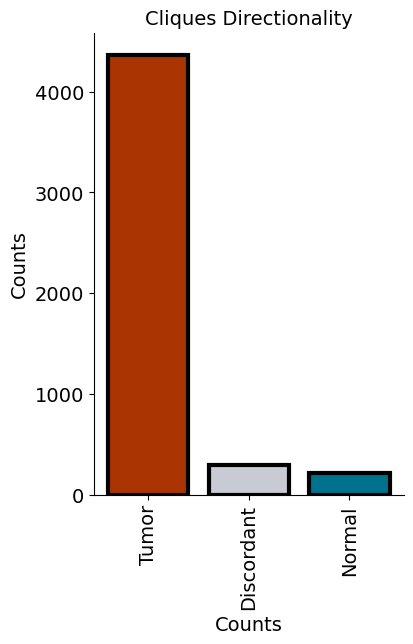

In [31]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.image as mpimg
import os

fs = 14

# Create the custom colormap and normalize the z-scores
cmap = mcolors.LinearSegmentedColormap.from_list('custom_gradient', ['white', tcolor])
colors = cmap(norm(counts))

# Create the bar plot
fig, ax = plt.subplots(1, 1, figsize=(4, 6))

bars = ax.bar(
    x=counts.index,
    height=counts.values,
    color=[tcolor, lightgray, ncolor],
    edgecolor='k',
    linewidth=3,
)

ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(labelsize=fs)

# Customize the plot
ax.set_title("Cliques Directionality", fontsize=fs)
ax.set_xlabel("Condition", fontsize=fs)
ax.set_ylabel("Counts", fontsize=fs)
plt.xticks(rotation=90)
ax.set_xlabel('Counts')


#plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/crosstalk/cliques_directionality.pdf', bbox_inches='tight', dpi=300)
#plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/crosstalk/cliques_directionality.png', bbox_inches='tight')

plt.show()


In [32]:
tdens = pd.read_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/motifs/tumor/motifs_densities.csv' , index_col='interaction').query('motif == "4_clique"')
ndens = pd.read_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/motifs/normal/motifs_densities.csv', index_col='interaction').query('motif == "4_clique"')
bdens = pd.read_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/motifs/both/motifs_densities.csv'  , index_col='interaction').query('motif == "4_clique"')

In [35]:
# Get more co-expressed in normal cliques
ndf = ndens[[col for col in ndens.columns if col not in ['motif', 'avg_all', 'avg_normal', 'avg_tumor']]].melt(var_name='tissue', ignore_index=False).reset_index()
ndf['condition'] = np.where(ndf['tissue'].str.startswith('normal_'), 'normal', 'tumor')
ndf['tissue'] = ndf['tissue'].str.replace('normal_', '').str.replace('tumor_', '').str.replace('.csv', '')

# Get more co-expressed in tumor cliques
tdf = tdens[[col for col in tdens.columns if col not in ['motif', 'avg_all', 'avg_normal', 'avg_tumor']]].melt(var_name='tissue', ignore_index=False).reset_index()
tdf['condition'] = np.where(tdf['tissue'].str.startswith('tumor_'), 'tumor', 'normal')
tdf['tissue'] = tdf['tissue'].str.replace('tumor_', '').str.replace('normal_', '').str.replace('.csv', '')

# Merge
mergedf = pd.concat([ndf, tdf])

# Only keep tissues with both tumor and normal
counts2 = mergedf.groupby(['interaction', 'tissue'])['condition'].nunique()
tissues = counts2[counts2 == 2].reset_index().tissue.unique()
mergedf = mergedf.query('tissue in @tissues')

# Pivot the data
pivot_df = mergedf.pivot_table(
    index=["interaction", "tissue"],  # Use interaction and tissue as indices
    columns="condition",             # Pivot on condition (tumor/normal)
    values="value"                   # Use value column to calculate differences
).reset_index()

# Compute the difference (tumor - normal)
pivot_df['difference'] = pivot_df['tumor'] - pivot_df['normal']
pivot_df = pivot_df.query('normal !=0  and tumor !=0')

pivot_df = pivot_df.sort_values(by='difference')

In [36]:
import networkx as nx
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt

def plot_gene_network(genes, tissue, savepath=None, edge_scaling=20, node_size=3500, linewidths=3, fs=16, min_width=0.1):
    """
    Plots two network graphs: one based on ncorr and one based on tcorr.

    Parameters:
        genes (list): List of gene names to consider for the graph.
        edge_scaling (int, optional): Multiplier for edge thickness.
        min_width (float, optional): Minimum edge width to ensure all edges are visible.
        node_size (int, optional): Size of the nodes. 
        linewidths (int, optional): Line width for node borders.
        fs (int, optional): Font size for labels.
    """
    global ncorr, tcorr  # Access the global variables ncorr and tcorr
    
    tissue = tissue.title().replace(' And ', ' & ')
    edgecolor = 'k'

    G_nc = nx.Graph()
    G_tc = nx.Graph()

    G_nc.add_nodes_from(genes)
    G_tc.add_nodes_from(genes)

    # Add edges with all correlations (even negative)
    for i in range(len(genes)):
        for j in range(i + 1, len(genes)):
            G_nc.add_edge(genes[i], genes[j], weight=ncorr.loc[genes[i], genes[j]])
            G_tc.add_edge(genes[i], genes[j], weight=tcorr.loc[genes[i], genes[j]])

    fig, axes = plt.subplots(2, 1, figsize=(5, 10))
    
    for ax, G, corr_matrix, title in zip(axes, [G_tc, G_nc], [tcorr, ncorr], ['Tumor', 'Normal']):
        ax.axis("off")

        # Get raw weights and apply edge scaling, clipping to min_width
        weights = [G[u][v]['weight'] for u, v in G.edges()]
        scaled_weights = [max(abs(w) * edge_scaling, min_width) for w in weights]

        pos = {
            genes[0]: (0.8, 0.8), genes[1]: (0.2, 0.8),
            genes[2]: (0.8, 0.2), genes[3]: (0.2, 0.2)
        }

        # Highlight specific edges (CCI edges) only if strong enough
        if genes[1] in G[genes[0]]:
            weight = abs(G[genes[0]][genes[1]]['weight'])
            if weight * edge_scaling > min_width:
                nx.draw_networkx_edges(
                    G, pos,
                    edgelist=[(genes[0], genes[1])],
                    width=weight * edge_scaling,
                    alpha=1,
                    edge_color='C1',
                    ax=ax
                )

        if genes[3] in G[genes[2]]:
            weight = abs(G[genes[2]][genes[3]]['weight'])
            if weight * edge_scaling > min_width:
                nx.draw_networkx_edges(
                    G, pos,
                    edgelist=[(genes[2], genes[3])],
                    width=weight * edge_scaling,
                    alpha=1,
                    edge_color='C0',
                    ax=ax
                )

        # Draw full graph
        nx.draw(
            G,
            pos,
            with_labels=False,
            node_color=2 * ['C1'] + 2 * ['C0'],
            edge_color=edgecolor,
            width=scaled_weights,
            node_size=node_size,
            font_size=fs,
            edgecolors=edgecolor,
            linewidths=linewidths,
            ax=ax
        )

        # Add custom text labels with outline
        for node, (x, y) in pos.items():
            label = node.replace("_", "\n")
            text = ax.text(
                x, y, label,
                fontsize=fs,
                ha='center', va='center',
                color='black'
            )
            text.set_path_effects([
                path_effects.Stroke(linewidth=8, foreground='white'),
                path_effects.Normal()
            ])

        # Edge label formatting: show ≤0 if abs(weight) < 0.01
        labels = nx.get_edge_attributes(G, "weight")
        formatted_labels = {
            edge: ("≤0" if abs(weight) <= 0 else f"{weight:.2f}")
            for edge, weight in labels.items()
        }

        diagonal_labels = {}
        other_labels = {}

        for k, v in formatted_labels.items():
            if (genes[0] in k and genes[3] in k) or (genes[1] in k and genes[2] in k):
                diagonal_labels[k] = v
            else:
                other_labels[k] = v

        nx.draw_networkx_edge_labels(G, pos, edge_labels=diagonal_labels, label_pos=0.25, ax=ax)
        nx.draw_networkx_edge_labels(G, pos, edge_labels=other_labels, label_pos=0.5, ax=ax)

        ax.set_title(f'{tissue}, {title}', fontsize=fs, y=0.96)

    plt.subplots_adjust(left=-0.05, right=1.05, top=1.05, bottom=-0.05)
    
    if savepath is not None:
        plt.savefig(savepath + '.pdf', bbox_inches='tight', dpi=300)
        plt.savefig(savepath + '.png', bbox_inches='tight', dpi=300)
    else:
        plt.show()


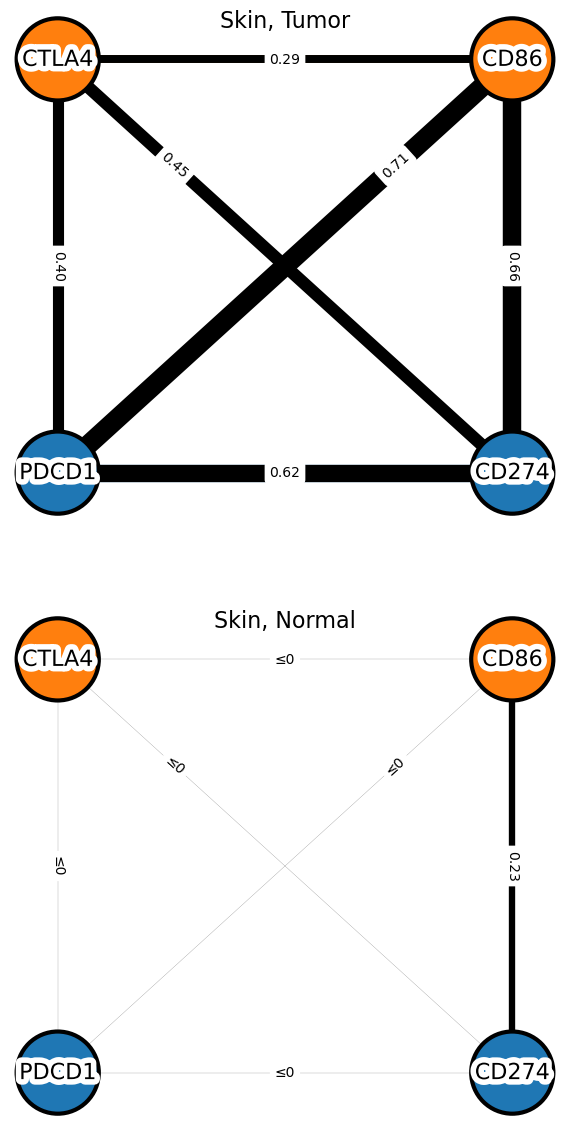

In [37]:
import os
import re

# === MANUAL INPUT ===
interaction = 'CD86+CTLA4&CD274+PDCD1'  # <-- your chosen interaction
tissue = 'skin'                        # <-- your chosen tissue

genes = re.split('[+&]', interaction)

# === PATHS ===
corr_path = '/home/lnemati/pathway_crosstalk/data/networks'

# === LOAD CORRELATION MATRICES FOR SELECTED TISSUE ===
ncorr = network_to_adj(os.path.join(corr_path, 'normal', tissue + '.csv.gz'))
tcorr = network_to_adj(os.path.join(corr_path, 'tumor',  tissue + '.csv.gz'))

# === PLOT NETWORK ===
try:
    plot_gene_network(genes, tissue, savepath=None)
except Exception as e:
    print(f"Failed to plot {interaction} in {tissue}: {e}")


In [38]:
import os
import re
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import networkx as nx

def plot_multiple_gene_networks(interactions_and_tissues, corr_path, savepath=None, edge_scaling=20, node_size=5000, linewidths=3, fs=21, min_width=0.1):
    """
    Plots multiple gene interaction networks as columns with tumor (top) and normal (bottom) rows.

    Parameters:
        interactions_and_tissues (list): List of (interaction_string, tissue) tuples.
        corr_path (str): Path to correlation matrices.
        savepath (str): If provided, saves the figure.
    """
    num_cols = len(interactions_and_tissues)
    fig, axes = plt.subplots(2, num_cols, figsize=(5 * num_cols, 10))
    if num_cols == 1:
        axes = axes.reshape(2, 1)  # Make 2x1 if only one column

    for col, (interaction, tissue) in enumerate(interactions_and_tissues):
        genes = re.split(r'[+&]', interaction)
        
        # Manually reorder:
        if genes == ['CCL2', 'CCR2', 'PDCD1', 'PDCD1LG2']:
            genes = ['CCL2', 'CCR2' , 'PDCD1LG2', 'PDCD1']
            
        tissue_clean = tissue.title().replace(' And ', ' & ')

        # Load correlation matrices
        ncorr = network_to_adj(os.path.join(corr_path, 'normal', tissue + '.csv.gz'))
        tcorr = network_to_adj(os.path.join(corr_path, 'tumor',  tissue + '.csv.gz'))

        for row, (corr_matrix, title) in enumerate([(tcorr, 'Tumor'), (ncorr, 'Normal')]):
            G = nx.Graph()
            G.add_nodes_from(genes)
            for i in range(len(genes)):
                for j in range(i + 1, len(genes)):
                    G.add_edge(genes[i], genes[j], weight=corr_matrix.loc[genes[i], genes[j]])

            ax = axes[row, col]
            ax.axis("off")

            #weights = [G[u][v]['weight'] for u, v in G.edges()]
            #scaled_weights = [max(abs(w) * edge_scaling, min_width) for w in weights]
            weights = [G[u][v]['weight'] for u, v in G.edges()]
            scaled_weights = [max(w * edge_scaling, min_width) if w > 0 else min_width for w in weights]

            pos = {
                genes[0]: (0.66, 0.66), genes[1]: (0.33, 0.66),
                genes[2]: (0.66, 0.33), genes[3]: (0.33, 0.33)
            }

            ## Highlight key edges
            #if genes[1] in G[genes[0]]:
            #    weight = abs(G[genes[0]][genes[1]]['weight'])
            #    if weight * edge_scaling > min_width:
            #        nx.draw_networkx_edges(
            #            G, pos, edgelist=[(genes[0], genes[1])],
            #            width=weight * edge_scaling, alpha=1,
            #            edge_color='C1', ax=ax
            #        )
            #
            #if genes[3] in G[genes[2]]:
            #    weight = abs(G[genes[2]][genes[3]]['weight'])
            #    if weight * edge_scaling > min_width:
            #        nx.draw_networkx_edges(
            #            G, pos, edgelist=[(genes[2], genes[3])],
            #            width=weight * edge_scaling, alpha=1,
            #            edge_color='C0', ax=ax
            #        )

            nx.draw(
                G, pos, with_labels=False,
                node_color=2 * ['C1'] + 2 * ['C0'],
                edge_color='k', width=scaled_weights,
                node_size=node_size, font_size=fs,
                edgecolors='k', linewidths=linewidths, ax=ax
            )

            for node, (x, y) in pos.items():
                label = node.replace("_", "\n")
                text = ax.text(x, y, label, fontsize=fs, ha='center', va='center', color='black')
                text.set_path_effects([
                    path_effects.Stroke(linewidth=8, foreground='white'),
                    path_effects.Normal()
                ])

            # Edge labels (≤0 if very small)
            labels = nx.get_edge_attributes(G, "weight")
            formatted_labels = {
                edge: ("≤0" if weight < 0.01 else f"{weight:.2f}")
                for edge, weight in labels.items()
            }

            diag_labels = {}
            other_labels = {}
            for k, v in formatted_labels.items():
                if (genes[0] in k and genes[3] in k) or (genes[1] in k and genes[2] in k):
                    diag_labels[k] = v
                else:
                    other_labels[k] = v

            nx.draw_networkx_edge_labels(G, pos, edge_labels=diag_labels, label_pos=0.25, ax=ax, font_size=fs)
            nx.draw_networkx_edge_labels(G, pos, edge_labels=other_labels, label_pos=0.5, ax=ax, font_size=fs)

            ax.set_title(f'{tissue_clean}, {title}', fontsize=fs, y=0.96)

    plt.subplots_adjust(left=-0.11, right=1.11, top=1.1, bottom=-0.1, wspace=0.06, hspace=0.015)

    if savepath:
        plt.savefig(savepath + '.pdf', bbox_inches='tight', dpi=300)
        plt.savefig(savepath + '.png', bbox_inches='tight', dpi=300)
    else:
        plt.show()


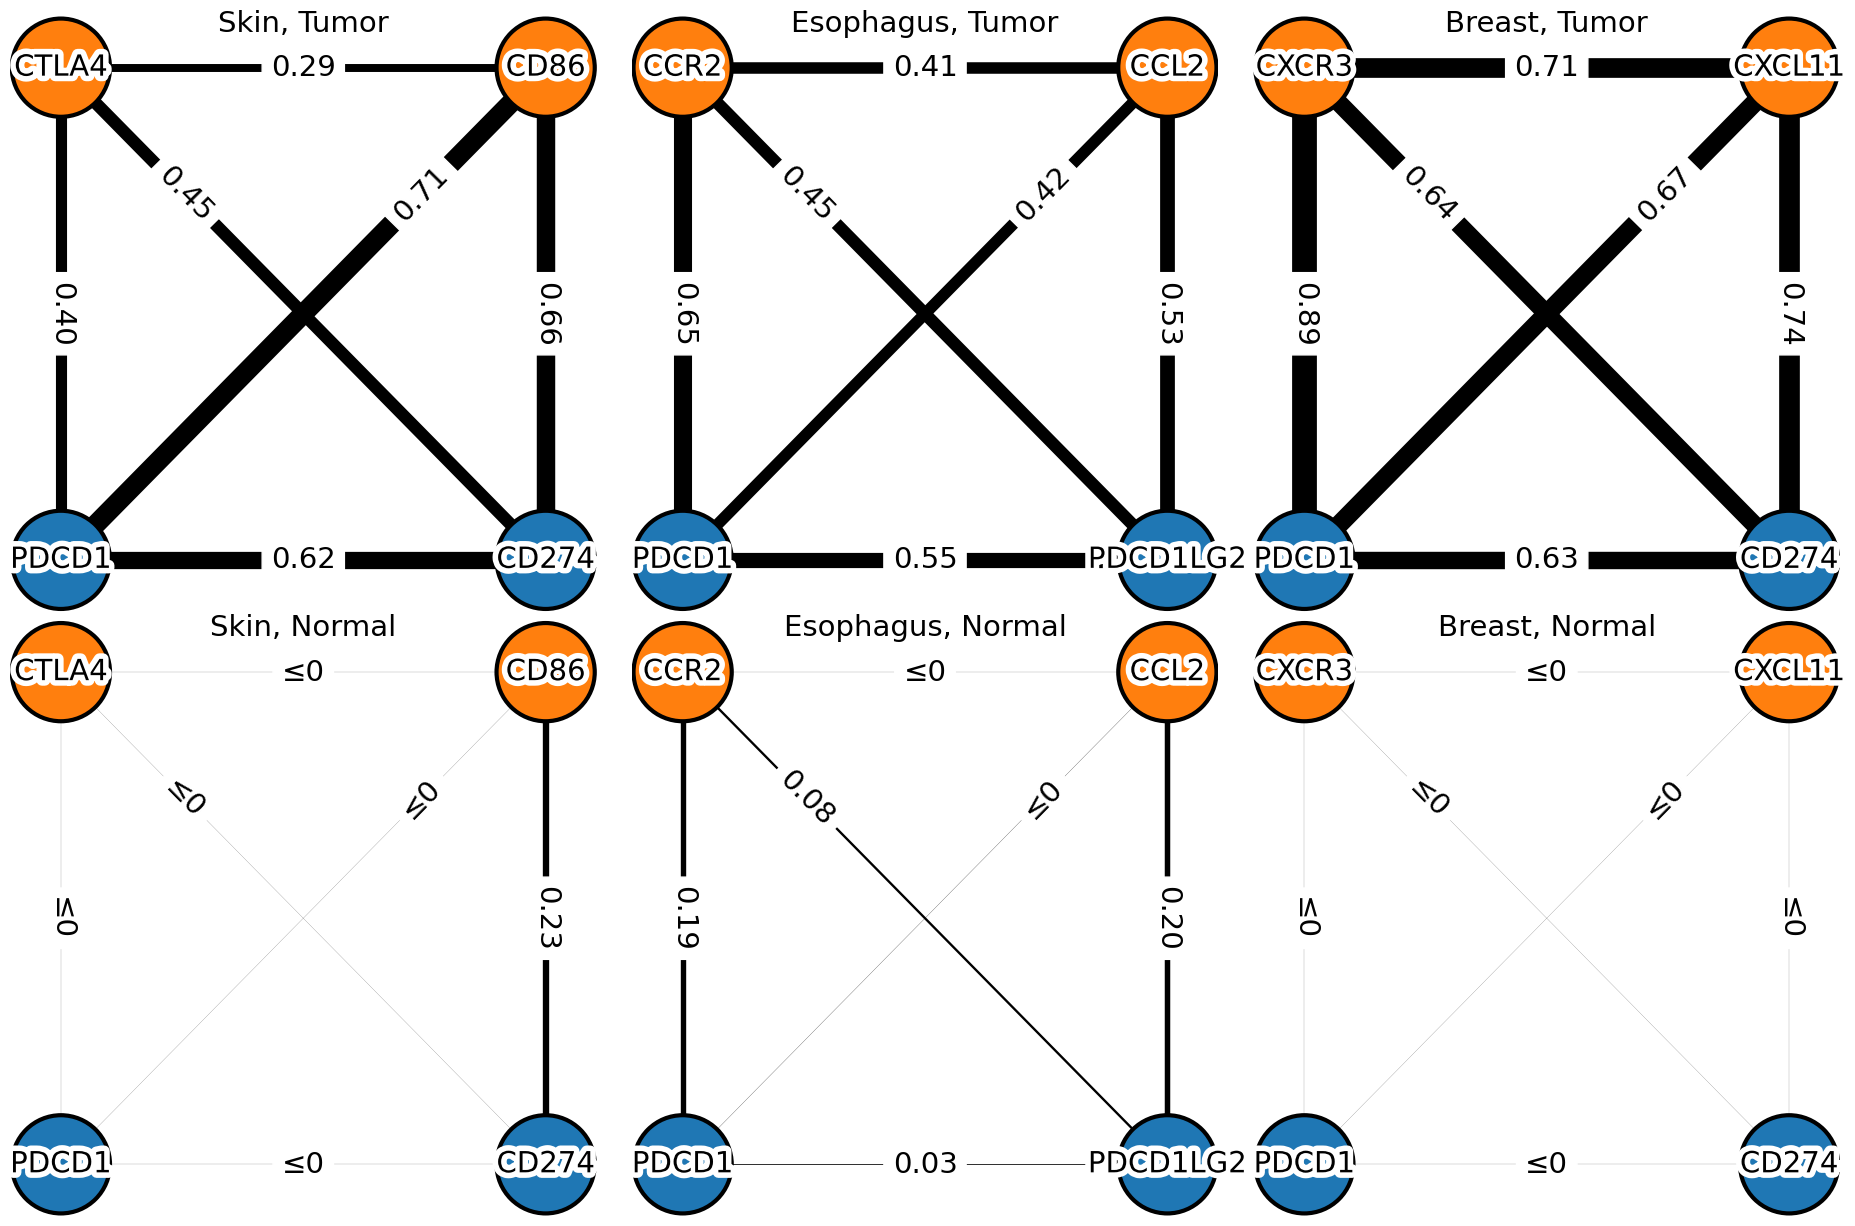

In [39]:
corr_path = '/home/lnemati/pathway_crosstalk/data/networks'

interactions_and_tissues = [
    ('CD86+CTLA4&CD274+PDCD1', 'skin'),
    ('CCL2+CCR2&PDCD1+PDCD1LG2', 'esophagus'), #suppl
    #('CXCL11+CXCR3&CD274+PDCD1', 'stomach'),
    ('CXCL11+CXCR3&CD274+PDCD1', 'breast'),
]

plot_multiple_gene_networks(
    interactions_and_tissues,
    corr_path,
    #savepath="/home/lnemati/pathway_crosstalk/results/figures/crosstalk/immune_checkpoints_cliques_rectangle"
)


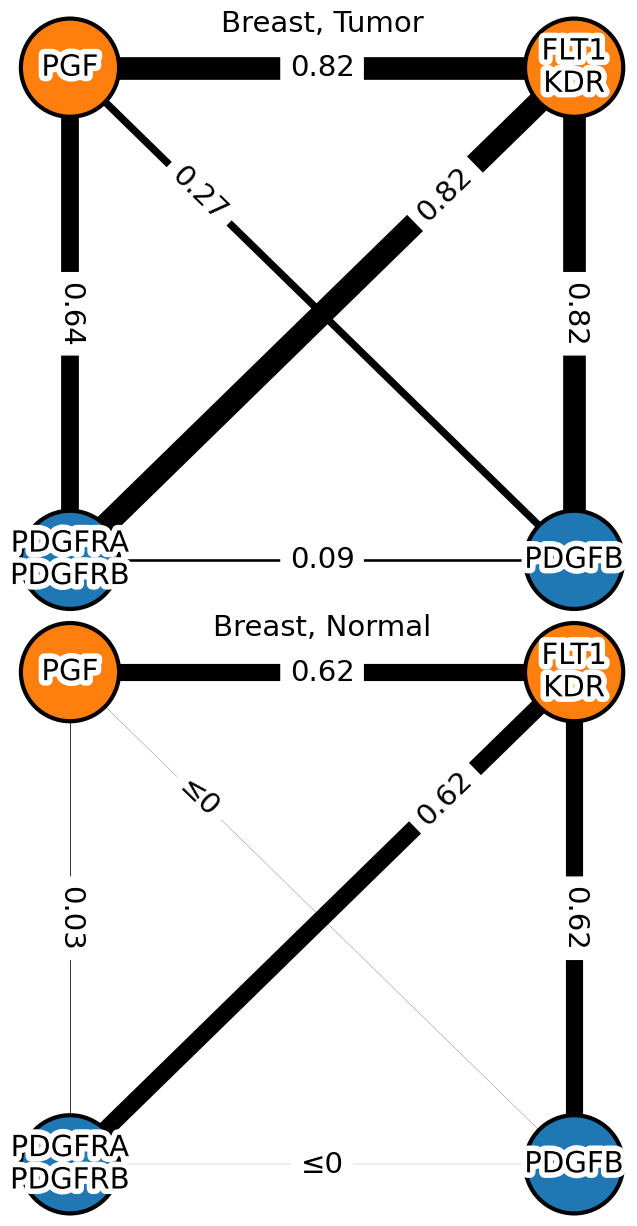

In [40]:
corr_path = '/home/lnemati/pathway_crosstalk/data/networks'

interactions_and_tissues = [
    ('FLT1_KDR+PGF&PDGFB+PDGFRA_PDGFRB', 'breast'),
]

plot_multiple_gene_networks(
    interactions_and_tissues,
    corr_path,
    #savepath="/home/lnemati/pathway_crosstalk/results/figures/crosstalk/targetable_clique"
)


In [41]:
# (CD86+CTLA4&CD274+PDCD1, skin)
# (CCL2+CCR2&PDCD1+PDCD1LG2) esophagus # supple, diff ligand
# (CXCL11+CXCR3&CD274+PDCD1, stomach)
# (CXCL11+CXCR3&CD274+PDCD1, breast)
# (CXCL11+CXCR3&CD274+PDCD1, lung) #supplementary
# (CXCL11+CXCR3&CD274+PDCD1, skin)
# (TNF+TNFRSF1B&CD69+KLRB1, breast) #supplementary
# (COL10A1+ITGA2_ITGB1&ACVR1_TGFBR1_TGFBR2+TGFB3, stomach) # supplementary
# (COL10A1+ITGA11_ITGB1&SFRP4+WNT2, stomach) #supplementary
# (COL10A1+ITGA11_ITGB1&FN1+ITGAV_ITGB5, pancreas) #supplementary


# Drugs

In [42]:
import xml.etree.ElementTree as ET
#tree = ET.parse('/home/carora/full database.xml')

tree = ET.parse('/projects/bioinformatics/DB/DRUGBANK/v5.1.13/full database.xml')

In [43]:
# Load cliques
tumor_cliques = pd.read_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/motifs/tumor/motifs.csv')
tumor_cliques = tumor_cliques.query('Type in ["3_clique", "4_clique"]')
tumor_cliques['all_genes'] = tumor_cliques['Interaction'].apply(lambda x: re.split(r'[+_^&]', x))
tumor_cliques['int1'] = tumor_cliques['Interaction'].apply(lambda x: re.split(r'[+_^]', x.split('&')[0]))
tumor_cliques['int2'] = tumor_cliques['Interaction'].apply(lambda x: re.split(r'[+_^]', x.split('&')[1]))


In [44]:
import pandas as pd
import numpy as np
import xml.etree.ElementTree as ET
from collections import defaultdict

#tree = ET.parse('/home/carora/full database.xml')

def get_drug_dbank(genes, tree=tree):
    root = tree.getroot()
    ns = {'db': 'http://www.drugbank.ca'}
    drugbank = root

    genes_set = set(genes)
    grouped_results = defaultdict(lambda: {'actions': set(), 'approvals': set()})

    for drug in drugbank.findall('.//db:drug', ns):
        drug_name_el = drug.find('.//db:name', ns)
        drug_name = drug_name_el.text if drug_name_el is not None else None
        groups = [g.text for g in drug.findall('.//db:groups/db:group', ns)]
        valid_approvals = [g for g in groups if g in {'approved', 'investigational'}]

        if not valid_approvals:
            continue

        for target in drug.findall('.//db:targets/db:target', ns):
            actions = [a.text if a is not None else np.nan for a in target.findall('.//db:actions/db:action', ns)]
            proteins = target.findall('.//db:polypeptide', ns)

            for protein in proteins:
                gene_symbol_el = protein.find('.//db:gene-name', ns)
                if gene_symbol_el is None:
                    continue

                gene_symbol = gene_symbol_el.text
                if gene_symbol not in genes_set:
                    continue

                key = (gene_symbol, drug_name)
                grouped_results[key]['actions'].update(actions)
                grouped_results[key]['approvals'].update(valid_approvals)

    # Format final results
    formatted_results = [
        {
            'gene': gene,
            'drug': drug,
            'action': sorted(list(data['actions'])),
            'approval': sorted(list(data['approvals']))
        }
        for (gene, drug), data in grouped_results.items()
    ]

    return pd.DataFrame(formatted_results).reset_index(drop=True)

def read_gmt(file_path):
    gene_sets = {}
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) >= 3:
                gene_sets[parts[0]] = set(parts[2:])
    return gene_sets

hallmarks_path = '/home/lnemati/resources/msigdb_hallmarks/h.all.v2024.1.Hs.symbols.gmt'
hallmarks = read_gmt(hallmarks_path)

all_clique_genes = list(set(tumor_cliques.all_genes.sum()))

drugs_df = get_drug_dbank(all_clique_genes)

drugs_df['hallmarks'] = drugs_df['gene'].apply(
    lambda gene: [h for h, genes in hallmarks.items() if gene in genes]
)

drugs_exploded = drugs_df.explode('approval').explode('action').explode('hallmarks').reset_index(drop=True)

#drugs_df.to_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/motifs/tumor/drugs.csv', index=False)
#drugs_exploded.to_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/motifs/tumor/drugs_exploded.csv', index=False)

In [45]:
from itertools import product
import pandas as pd

# Clean the drug dataset: keep only drugs with action and approved status
clean_df = drugs_df.copy()
clean_df = clean_df[clean_df.action.apply(lambda x: len(x) > 0)]
clean_df = clean_df[clean_df.approval.apply(lambda x: 'approved' in x)]

# Create lookup dictionaries
drug_to_action = clean_df.groupby('drug')['action'].first().to_dict()
drug_to_targets = clean_df.groupby('drug')['gene'].apply(list).to_dict()

all_drug_pairs = []

for idx, row in tumor_cliques.iterrows():
    clique = row.Interaction
    genes1 = row.int1
    genes2 = row.int2

    # Ensure genes1 and genes2 are lists (e.g., if stored as strings)
    if isinstance(genes1, str):
        genes1 = eval(genes1)
    if isinstance(genes2, str):
        genes2 = eval(genes2)

    # Filter drugs by genes in each group
    drugs1 = clean_df.query('gene in @genes1')
    drugs2 = clean_df.query('gene in @genes2')

    # Create unique drug pairs
    combinations = product(drugs1['drug'], drugs2['drug'])

    for drug1, drug2 in combinations:
        if drug1 != drug2:
            action1 = drug_to_action.get(drug1, [])
            action2 = drug_to_action.get(drug2, [])
            targets1 = drug_to_targets.get(drug1, [])
            targets2 = drug_to_targets.get(drug2, [])
            
            # Also make sure they are not targetting the same gene
            if not set(targets1).intersection(genes1).issubset(set(targets2).intersection(genes2)):

                all_drug_pairs.append({
                    'clique': clique,
                    'drug1': drug1,
                    'targets1': targets1,
                    'action1': action1,
                    'drug2': drug2,
                    'targets2': targets2,
                    'action2': action2,
                    'actions_combined': sorted(set(action1 + action2))
                })

# Create the final DataFrame
drug_pairs_df = pd.DataFrame(all_drug_pairs)

In [46]:
antibodies = pd.read_csv('/home/lnemati/pathway_crosstalk/data/antibodies.tsv', sep='\t', index_col=0, header=None)
antibodies = antibodies.index

In [47]:
drug_pairs_df['type1'] = 'Small Molecule'
drug_pairs_df['type2'] = 'Small Molecule'
drug_pairs_df.loc[drug_pairs_df.drug1.isin(antibodies), 'type1'] = 'Antibody'
drug_pairs_df.loc[drug_pairs_df.drug2.isin(antibodies), 'type2'] = 'Antibody'

In [48]:
drug_pairs_df['unique_id'] = drug_pairs_df[['clique', 'drug1', 'drug2']].apply(lambda x: tuple(sorted(x)), axis=1)
drug_pairs_df = drug_pairs_df[~drug_pairs_df.unique_id.duplicated()]
drug_pairs_df = drug_pairs_df[['clique', 'drug1', 'targets1', 'type1', 'drug2', 'targets2', 'type2']]
#drug_pairs_df.to_csv('/home/lnemati/pathway_crosstalk/results/crosstalk/all_ccc_complex_pairs/adj/motifs/tumor/approved_drug_pairs.csv', index=False)

In [49]:
# Sort the type pairs alphabetically so ('Antibody', 'Small Molecule') and ('Small Molecule', 'Antibody') are treated the same
sorted_pairs = drug_pairs_df[['type1', 'type2']].apply(lambda x: tuple(sorted(x)), axis=1)

# Count the value occurrences of these sorted tuples
drug_type_counts = sorted_pairs.value_counts()

In [50]:
print(drug_pairs_df.clique.nunique())
drug_pairs_df.clique.value_counts().head(10)

1567


clique
FLT1_KDR+VEGFB&TNF+TNFRSF1A              417
FLT1_KDR+PGF&PDGFB+PDGFRA_PDGFRB         357
TNF+TNFRSF1B&CD274+PDCD1                 228
AOC1+HRH1&HNMT+HRH1                      201
PDGFB+PDGFRA_PDGFRB&ITGAV_ITGB6+TGFB1    186
PDGFB+PDGFRB&PDGFB+PDGFRA                185
PDCD1+PDCD1LG2&TNF+TNFRSF1B              171
TNF+TNFRSF1B&CD274+CD80                  171
ITGA4_ITGB1+PLAUR&PDGFB+PDGFRA_PDGFRB    147
ITGA4_ITGB1+VCAM1&TNF+TNFRSF1B           133
Name: count, dtype: int64

In [51]:
sorted_pairs = drug_pairs_df[['drug1', 'drug2']].apply(lambda x: tuple(sorted(x)), axis=1)
print(sorted_pairs.nunique())
sorted_pairs.value_counts().head(10)

5415


(Antithymocyte immunoglobulin (rabbit), Fostamatinib)                        162
(Antithymocyte immunoglobulin (rabbit), Ibalizumab)                          153
(Abatacept, Antithymocyte immunoglobulin (rabbit))                           138
(Antithymocyte immunoglobulin (rabbit), Belatacept)                          138
(Antithymocyte immunoglobulin (rabbit), Nintedanib)                          111
(Antithymocyte immunoglobulin (rabbit), Maraviroc)                           110
(Antithymocyte immunoglobulin (rabbit), Sunitinib)                           103
(Antithymocyte immunoglobulin (rabbit), Erdafitinib)                         103
(Chloroquine, Ibalizumab)                                                    101
(Antithymocyte immunoglobulin (rabbit), Foreskin keratinocyte (neonatal))    100
Name: count, dtype: int64

In [52]:
drug_type_counts.index = drug_type_counts.index.astype(str).str.replace('\'', '').str.replace('(', '').str.replace(')', '').str.replace(', ', '\n&\n')

In [53]:
drug_pairs_df.clique.nunique() / tumor_cliques.shape[0]

0.36399535423925666

In [54]:
targetable_cliques_counts = {}
targetable_cliques_counts['Antibody\n&\nAntibody'] = drug_pairs_df.query('type1 == "Antibody" and type2 == "Antibody"').clique.nunique()
targetable_cliques_counts['Small Molecule\n&\nSmall Molecule'] = drug_pairs_df.query('type1 == "Small Molecule" and type2 == "Small Molecule"').clique.nunique()
targetable_cliques_counts['Antibody\n&\nSmall Molecule'] = drug_pairs_df.query('type1 != type2').clique.nunique()
targetable_cliques_counts = pd.Series(targetable_cliques_counts).sort_values()

targetable_cliques_fracs = targetable_cliques_counts / tumor_cliques.shape[0]

In [55]:
# Get sets of cliques for each category
antibody_antibody_cliques = set(drug_pairs_df.query('type1 == "Antibody" and type2 == "Antibody"').clique.unique())
small_small_cliques = set(drug_pairs_df.query('type1 == "Small Molecule" and type2 == "Small Molecule"').clique.unique())
antibody_small_cliques = set(drug_pairs_df.query('type1 != type2').clique.unique())

# Compute overlaps
overlap_aa_ss = antibody_antibody_cliques & small_small_cliques
overlap_aa_as = antibody_antibody_cliques & antibody_small_cliques
overlap_ss_as = small_small_cliques & antibody_small_cliques
overlap_all = antibody_antibody_cliques & small_small_cliques & antibody_small_cliques

# Optionally, print counts
print(f"Antibody & Antibody ∩ Small Molecule & Small Molecule: {len(overlap_aa_ss) / tumor_cliques.shape[0]}")
print(f"Antibody & Antibody ∩ Antibody & Small Molecule: {len(overlap_aa_as) / tumor_cliques.shape[0]}")
print(f"Small Molecule & Small Molecule ∩ Antibody & Small Molecule: {len(overlap_ss_as) / tumor_cliques.shape[0]}")
print(f"All three overlap: {len(overlap_all)}")


Antibody & Antibody ∩ Small Molecule & Small Molecule: 0.03739837398373984
Antibody & Antibody ∩ Antibody & Small Molecule: 0.15284552845528454
Small Molecule & Small Molecule ∩ Antibody & Small Molecule: 0.08548199767711963
All three overlap: 161


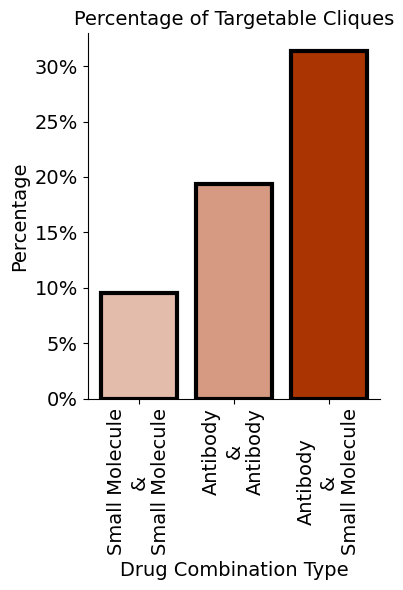

In [56]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mtick  # <-- Add this import
import numpy as np
import pandas as pd

fs = 14
drug_type_counts = drug_type_counts.sort_values()

# Normalize counts for coloring
norm = mcolors.Normalize(vmin=0, vmax=drug_type_counts.max())
cmap = mcolors.LinearSegmentedColormap.from_list('custom_gradient', ['white', tcolor])
colors = cmap(norm(drug_type_counts))

# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(4, 6))
bars = ax.bar(
    x=targetable_cliques_fracs.index,
    height=targetable_cliques_fracs.values,
    color=colors,
    edgecolor='k',
    linewidth=3,
)

# Beautify plot
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(labelsize=fs)
ax.set_title("Percentage of Targetable Cliques", fontsize=fs)
ax.set_xlabel("Drug Combination Type", fontsize=fs)
ax.set_ylabel("Percentage", fontsize=fs)  # Updated label

# Format y-axis as percentage
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))

plt.xticks(rotation=90)
plt.tight_layout()

# Show or save
plt.show()


# FULL FIGURE

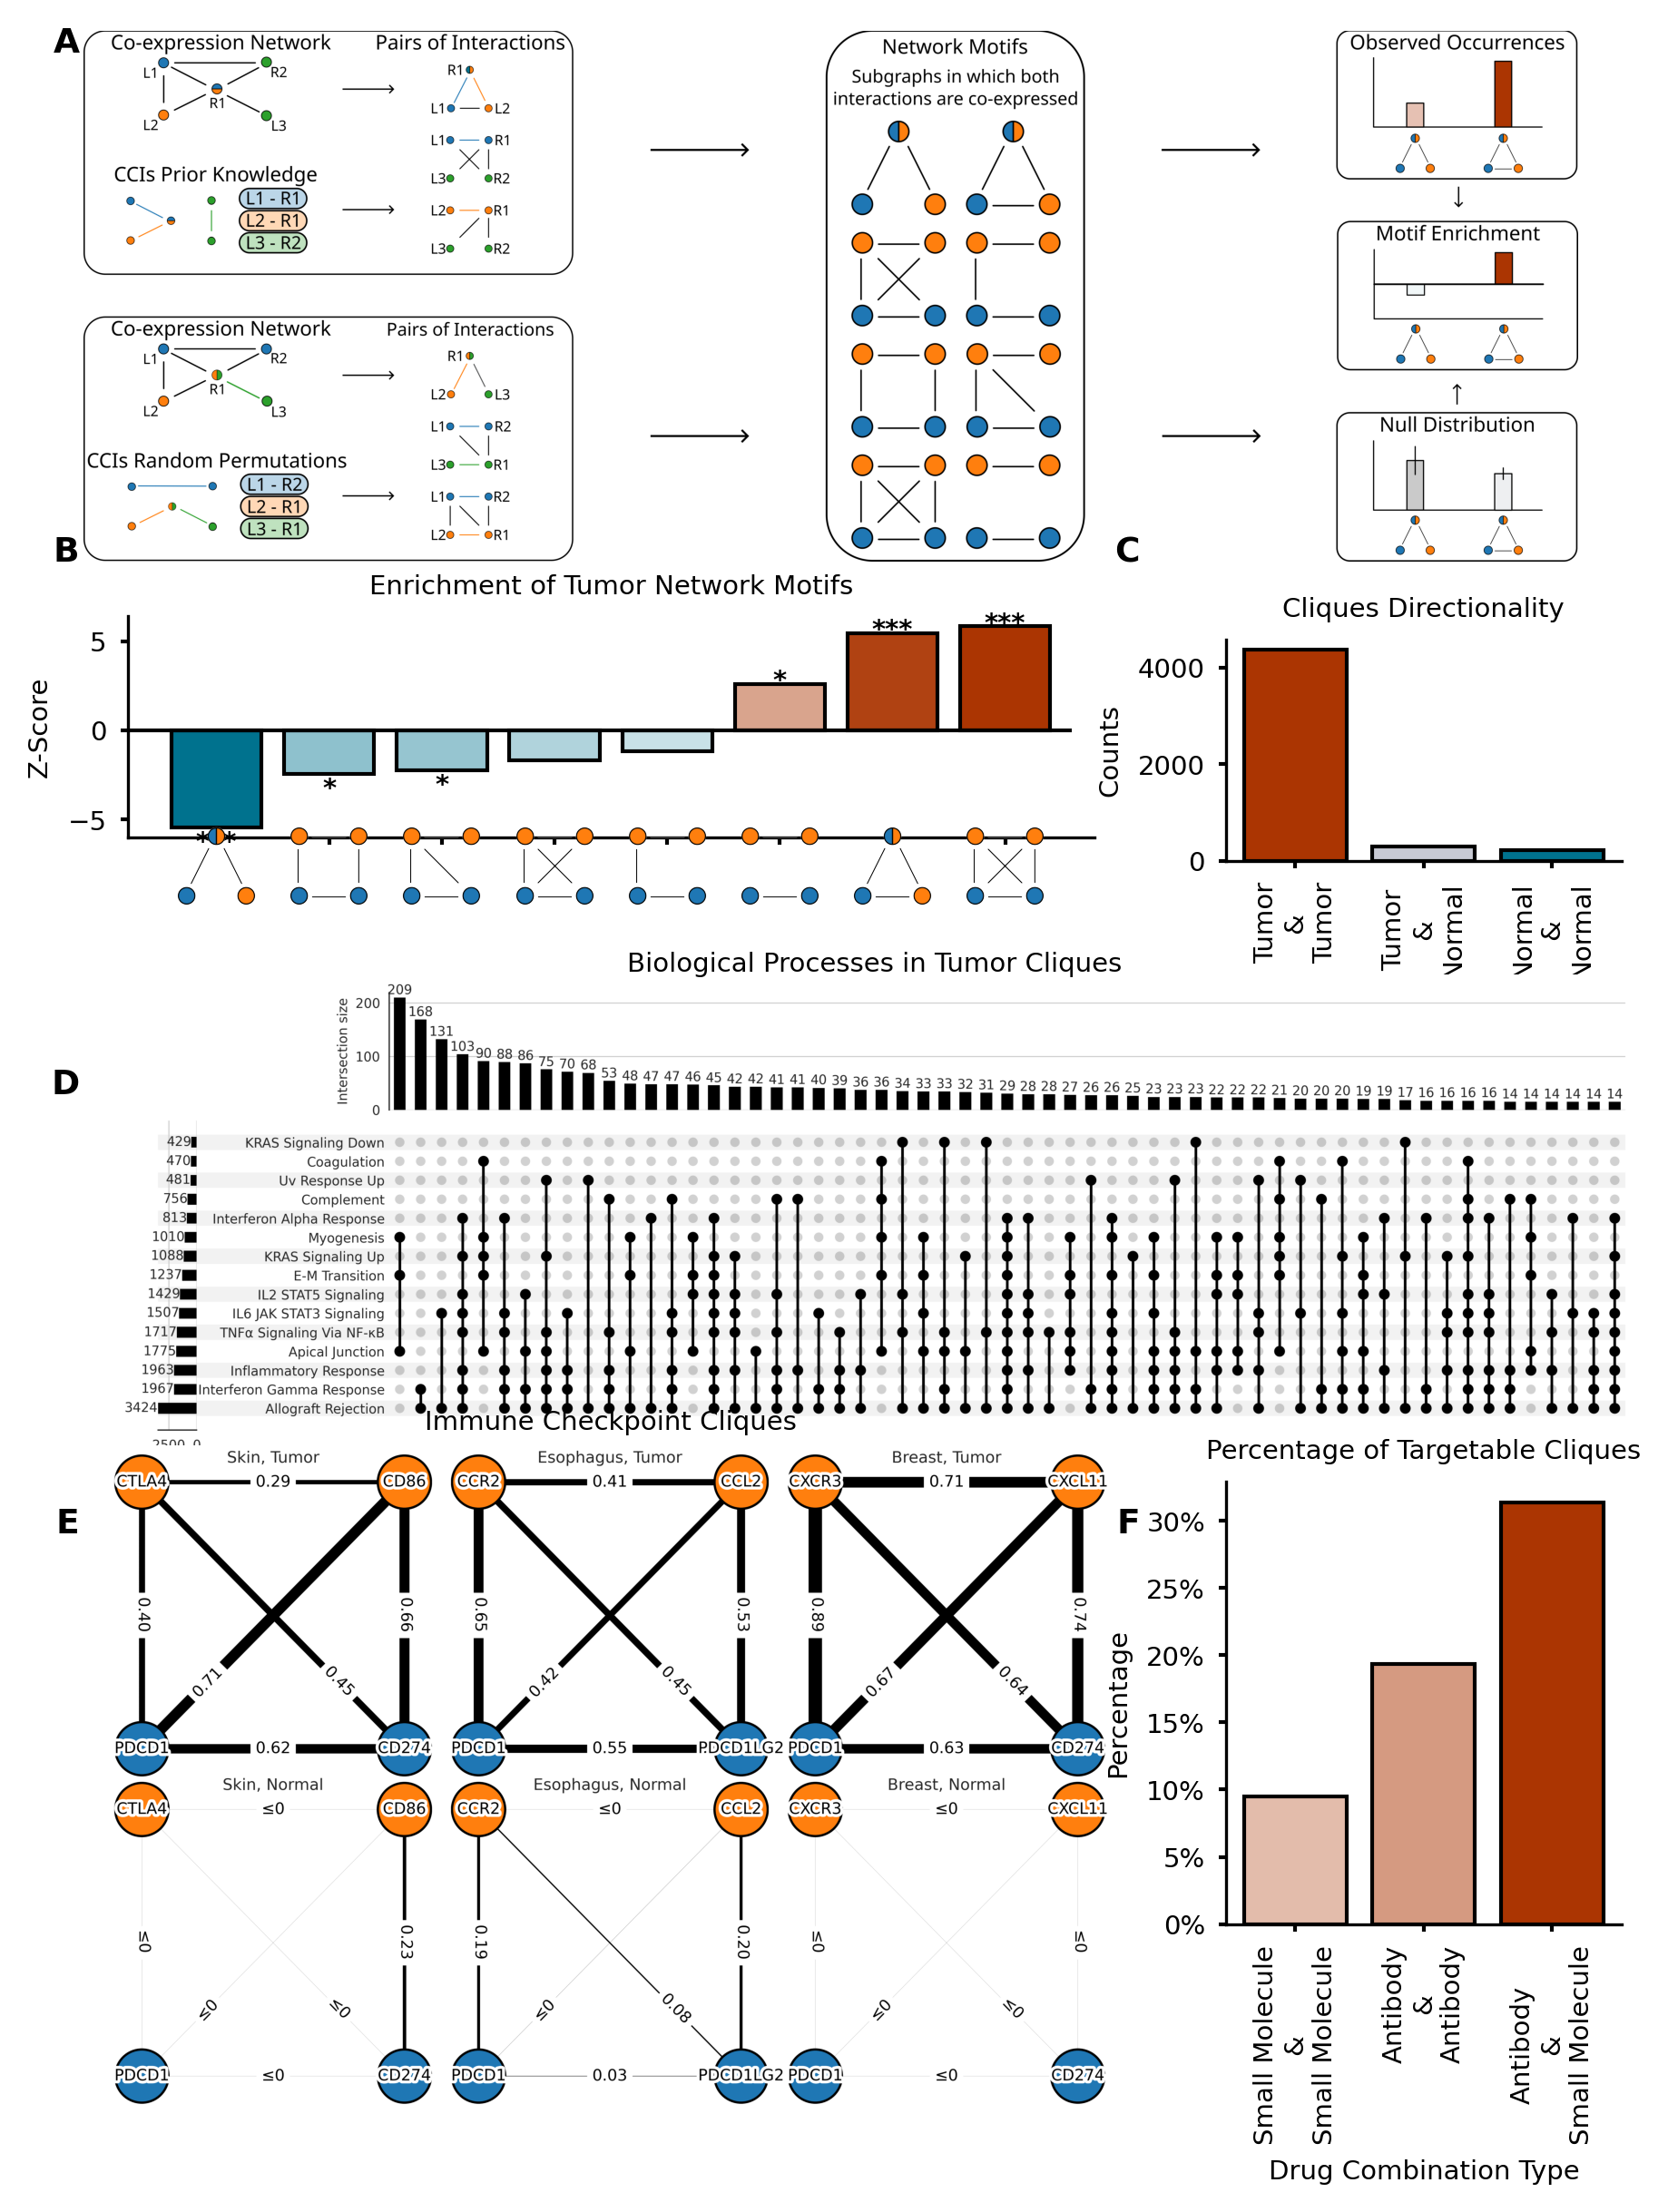

In [70]:
from PIL import Image, ImageChops
import matplotlib.image as mpimg
import matplotlib.colors as mcolors
import matplotlib.ticker as mtick

import os
fs = 7

# Create the figure and the layout
fig, axs = plt.subplot_mosaic(
    """
    AAA
    BBC
    DDD
    EEF
    """,
    dpi=300,
    figsize=(7.08, 8.5),
    height_ratios=[1,0.5,1,1]
)

#axs['X'].axis('off')

#fig.subplots_adjust(wspace=0.05, hspace=0.3)

## Manually adjust the spacing between B and D
## Shift D down and reduce its height a little to make room for icons under B
pos = {ax: axs[ax].get_position() for ax in axs}

# Create a small vertical gap between B and D
move_up = 0.07

# Move B and C up
for ax in axs:
    if ax in ['B', 'C']:
        axs[ax].set_position([
            pos[ax].x0,
            pos[ax].y0 + 0.01,
            pos[ax].width,
            pos[ax].height
        ])

axs['A'].set_position([
    pos['A'].x0-0.1,
    pos['A'].y0,
    pos['A'].width*1.2,
    pos['A'].height*1.2
])

axs['C'].set_position([
    pos['C'].x0 + pos['F'].width*0.1,
    pos['C'].y0,
    pos['C'].width*0.9,
    pos['C'].height
])
        
axs['D'].set_position([
    pos['D'].x0 - pos['D'].width*0.05,
    pos['D'].y0 - 0.035,
    pos['D'].width*1.1,
    pos['D'].height*1.1
])

axs['E'].set_position([
    pos['E'].x0 - pos['E'].width*0.25,
    pos['E'].y0 - 0.09,
    pos['E'].width*1.5,
    pos['E'].height*1.5
])

axs['F'].set_position([
    pos['F'].x0 + pos['F'].width*0.1,
    pos['F'].y0-0.01,
    pos['F'].width*0.9,
    pos['F'].height
])


############# AXIS A: Workflow ##############

ax = axs['A']
img_path = "/home/lnemati/pathway_crosstalk/data/motifs_icons/motifs_workflow_large.png"

img = Image.open(img_path).convert("RGB")

ax.imshow(img)
ax.axis('off')

############# AXIS B: Motif Enrichment Bar Plot with Icons ##############

ax = axs['B']
fig = ax.figure
img_dir = '/home/lnemati/pathway_crosstalk/data/motifs_icons'

# Get motifs and z-scores
motifs = motifs_z.index
z_scores = motifs_z.values

# Color mapping
cmap = mcolors.LinearSegmentedColormap.from_list('custom_gradient', [ncolor, 'white', tcolor])
norm = mcolors.TwoSlopeNorm(vmin=z_scores.min(), vcenter=0, vmax=z_scores.max())
colors = cmap(norm(z_scores))

# Create bars
bars = ax.bar(motifs, z_scores, color=colors, edgecolor='k', linewidth=1)

# Add zero line
xlim = ax.get_xlim()
#ax.hlines(0, *xlim, color='k', linestyle='-', linewidth=3)
ax.hlines(0, xlim[0], xlim[1]-0.2, color='k', linestyle='-', linewidth=1)
ax.set_xlim(xlim)

# Clean up axes
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(labelsize=fs)
ax.set_title("Enrichment of Tumor Network Motifs", fontsize=fs)
ax.set_ylabel("Z-Score", fontsize=fs)
ax.set_xticklabels([])
#ax.set_xlabel("Motif", fontsize=fs)
ax.set_xlabel("Motif", fontsize=fs, labelpad=50)

img_width = 0.7
img_height = img_width
y_icons_offset = 0.48

for tick_x, label in zip(ax.get_xticks(), motifs):
    img_path = os.path.join(img_dir, f"{label}.png")
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        
        # Create an inset axis centered at the tick
        inset_ax = ax.inset_axes(
            [tick_x - img_width/2, -y_icons_offset, img_width, img_height],  # [x0, y0, width, height]
            transform=ax.get_xaxis_transform(),  # Align with x-axis ticks
            zorder=10
        )
        inset_ax.imshow(img)
        inset_ax.axis('off')

# === Add significance stars ===
sig_levels = {0.001: '***', 0.01: '**', 0.05: '*'}
for bar, z_score, p_val in zip(bars, z_scores, p_values):
    height = bar.get_height()
    sig_symbol = next((s for t, s in sig_levels.items() if p_val <= t), None)
    if sig_symbol:
        text_y = height + 0.15 if z_score > 0 else height - 0.15
        va = 'center' if z_score > 0 else 'top'
        ax.text(bar.get_x() + bar.get_width() / 2, text_y, sig_symbol,
                ha='center', va=va, fontsize=fs, fontweight='bold')

# Final axis cleanup
ax.tick_params(axis='both', which='both', labelsize=fs, direction='out', length=2, width=1, colors='black')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

# Create the custom colormap and normalize the z-scores
cmap = mcolors.LinearSegmentedColormap.from_list('custom_gradient', ['white', tcolor])
colors = cmap(norm(counts))

################ AXIS C: Cliques directionality
ax = axs['C']

counts.index = pd.Series(counts.index).replace({
    'Tumor': 'Tumor\n&\nTumor',
    'Discordant': 'Tumor\n&\nNormal',
    'Normal': 'Normal\n&\nNormal'
}).values

bars = ax.bar(
    x=counts.index,
    height=counts.values,
    color=[tcolor, lightgray, ncolor],
    edgecolor='k',
    linewidth=1,
)

ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(labelsize=fs)

# Customize the plot
ax.set_title("Cliques Directionality", fontsize=fs)
ax.set_xlabel("Condition", fontsize=fs)
ax.set_ylabel("Counts", fontsize=fs)
ax.tick_params(axis='x', labelrotation=90)
ax.set_xlabel('Counts')

ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.get_xaxis().set_visible(True)
ax.get_yaxis().set_visible(True)

ax.tick_params(
    axis='both',
    which='both',
    labelsize=fs,
    direction='out',
    length=2,
    width=1,
    colors='black'
)

############# AXIS D: UpSet Plot ##############

# Path to your saved UpSet PNG
upset_img_path = '/home/lnemati/pathway_crosstalk/results/figures/crosstalk/hallmarks/hallmarks_upset.png'

# Load the image
img = mpimg.imread(upset_img_path)

ax = axs['D']
ax.set_title('Biological Processes in Tumor Cliques', fontsize=fs, y=0.96)
ax.imshow(img)
ax.axis('off')  # Hide axes if desired

############# AXIS E: CLiques ##############

ax = axs['E']

# Path to image
#img_path = '/home/lnemati/pathway_crosstalk/results/results/figures/crosstalk/cliques_rectangle.png'
img_path = '/home/lnemati/pathway_crosstalk/results/figures/crosstalk/immune_checkpoints_cliques_rectangle.png'
img = mpimg.imread(img_path)
ax.set_title('Immune Checkpoint Cliques', fontsize=fs, y=0.99)
ax.imshow(img)
ax.axis('off')


################ AXIS F: Drugs ####################

ax = axs['F']

# Normalize counts for coloring
norm = mcolors.Normalize(vmin=0, vmax=drug_type_counts.max())
cmap = mcolors.LinearSegmentedColormap.from_list('custom_gradient', ['white', tcolor])
colors = cmap(norm(drug_type_counts))

# Create the plot
bars = ax.bar(
    x=targetable_cliques_fracs.index,
    height=targetable_cliques_fracs.values,
    color=colors,
    edgecolor='k',
    linewidth=1,
)

# Beautify plot
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(labelsize=fs)
ax.set_title("Percentage of Targetable Cliques", fontsize=fs)
ax.set_xlabel("Drug Combination Type", fontsize=fs)
ax.set_ylabel("Percentage", fontsize=fs)

# Format y-axis as percentage
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))

plt.xticks(rotation=90)

ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.get_xaxis().set_visible(True)
ax.get_yaxis().set_visible(True)

ax.tick_params(
    axis='both',
    which='both',
    labelsize=fs,
    direction='out',
    length=2,
    width=1,
    colors='black'
)

axs['A'].text(0.1, 0.92, 'A', fontsize=fs+2, fontweight='bold', transform=fig.transFigure, va='top', ha='right')
axs['B'].text(0.1, 0.7, 'B', fontsize=fs+2, fontweight='bold', transform=fig.transFigure, va='top', ha='right')
axs['C'].text(0.65, 0.7, 'C', fontsize=fs+2, fontweight='bold', transform=fig.transFigure, va='top', ha='right')
axs['D'].text(0.1, 0.47, 'D', fontsize=fs+2, fontweight='bold', transform=fig.transFigure, va='top', ha='right')
axs['E'].text(0.1, 0.28, 'E', fontsize=fs+2, fontweight='bold', transform=fig.transFigure, va='top', ha='right')
axs['F'].text(0.65, 0.28, 'F', fontsize=fs+2, fontweight='bold', transform=fig.transFigure, va='top', ha='right')

#plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/matplotlib_full_figures/fig4/fig4.svg', bbox_inches='tight', dpi=300)
#plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/matplotlib_full_figures/fig4/fig4.pdf', bbox_inches='tight', dpi=300)
#plt.savefig('/home/lnemati/pathway_crosstalk/results/figures/matplotlib_full_figures/fig4/fig4.png', bbox_inches='tight', dpi=300)
plt.savefig('/home/lnemati/pathway_crosstalk/results/revision/images/crosstalk_fig_smaller.svg', bbox_inches='tight', dpi=300)


plt.show()

In [175]:
#fig_to_panels(fig, axs, output_dir='/home/lnemati/pathway_crosstalk/results/figures/matplotlib_full_figures/fig4/panels')

Saved panel '' to /home/lnemati/pathway_crosstalk/results/figures/matplotlib_full_figures/fig4/panels/
Saved panel 'Enrichment of Tumor Network Motifs' to /home/lnemati/pathway_crosstalk/results/figures/matplotlib_full_figures/fig4/panels/enrichment_of_tumor_network_motifs
Saved panel 'Cliques Directionality' to /home/lnemati/pathway_crosstalk/results/figures/matplotlib_full_figures/fig4/panels/cliques_directionality
Saved panel 'Biological Processes in Tumor Cliques' to /home/lnemati/pathway_crosstalk/results/figures/matplotlib_full_figures/fig4/panels/biological_processes_in_tumor_cliques
Saved panel 'Immune Checkpoint Cliques' to /home/lnemati/pathway_crosstalk/results/figures/matplotlib_full_figures/fig4/panels/immune_checkpoint_cliques
Saved panel 'Percentage of Targetable Cliques' to /home/lnemati/pathway_crosstalk/results/figures/matplotlib_full_figures/fig4/panels/percentage_of_targetable_cliques
